<a href="https://colab.research.google.com/github/jieun0441/scaling_Korea/blob/main/Scaling1_Urban_Scaling_Data_Prep1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Frame Structure Creation

In [ ]:
import pandas as pd
from itertools import product

# ==========================================
# 1. city list prep
# ==========================================
file_path = '/content/drive/MyDrive/Urban Scaling/Scaling Project Dataset Frame_city_list and code.xlsx'
df_city_source = pd.read_excel(file_path)

# CRITICAL: Ensure 'City_Code' is treated as a string to preserve leading zeros (e.g., '02' instead of 2).
df_city_source['City_Code'] = df_city_source['City_Code'].astype(str)

# Extract unique city codes to be used as keys for the skeleton
unique_codes = df_city_source['City_Code'].unique()

print(f"Number of unique cities: {len(unique_codes)}")

Number of unique cities: 162


In [ ]:
# ==========================================
# 2. create year list (2000 ~ 2024)
# ==========================================
years = list(range(2000, 2025))

In [ ]:
# ========================================================
# [Step 3] Generate the Master Skeleton (Cartesian Product)
# ========================================================
# Create every possible combination of (Year x City_Code).
# This ensures a balanced panel structure where every city has a row for every year.
skeleton_data = list(product(years, unique_codes))

# Create a temporary DataFrame with just Year and City_Code
df_skeleton = pd.DataFrame(skeleton_data, columns=['Year', 'City_Code'])

In [ ]:
# ========================================================
# [Step 4] Merge Metadata back to the Skeleton
# ========================================================
# The skeleton currently only has 'Year' and 'Code'.
# We merge the original source data back to populate static columns (Names, Region Type, etc.) for every year.
df_final_skeleton = pd.merge(df_skeleton, df_city_source, on='City_Code', how='left')

In [ ]:
# ========================================================
# [Step 5] Sort and Reorder Columns
# ========================================================
# 1. Sort by Year first, then by City_Code for better readability
df_final_skeleton = df_final_skeleton.sort_values(by=['Year', 'City_Code'])

# 2. Reorder columns to matching your specific requirement
cols_order = [
    'Year',
    'City_Code',
    'province',
    'city_name',
    'City_name_Kor',
    'city_name_Eng',
    'Region_type'
]
df_final_skeleton = df_final_skeleton[cols_order]

In [ ]:
# ========================================================
# [Step 6] Verification and Export
# ========================================================
print("-" * 30)
print(f"Total rows generated: {len(df_final_skeleton)}")
print(f"Verification: {len(unique_codes)} cities x {len(years)} years = {len(unique_codes) * len(years)}")
print("-" * 30)
print(df_final_skeleton.head())

# Export to CSV
# 'utf-8-sig' is recommended for Korean characters (Hangul) support in Excel
df_final_skeleton.to_csv('/content/drive/MyDrive/Urban Scaling/Master_Panel_Skeleton_Final.csv', index=False, encoding='utf-8-sig')
print("Export completed: Master_Panel_Skeleton_Final.csv")

------------------------------
Total rows generated: 4050
Verification: 162 cities x 25 years = 4050
------------------------------
     Year City_Code province city_name City_name_Kor city_name_Eng Region_type
0    2000        11    서울특별시        서울         서울특별시         Seoul         SMA
1    2000        21    부산광역시        부산         부산광역시         Busan     Non-SMA
2    2000        22    대구광역시        대구         대구광역시         Daegu     Non-SMA
129  2000     22520     경상북도       군위군       경상북도군위군     Gunwi-gun     Non-SMA
3    2000        23    인천광역시        인천         인천광역시       Incheon         SMA
Export completed: Master_Panel_Skeleton_Final.csv


## merge population

In [ ]:
import pandas as pd

# ========================================================
# [Step 1] 뼈대 파일 로드 및 사전(Dictionary) 2개 준비
# ========================================================
df_master = pd.read_csv('/content/drive/MyDrive/Urban Scaling/Master_Panel_Skeleton_3.csv', dtype={'City_Code': str})

# 1. (기존) 긴 이름 매핑 사전: '경기수원시' -> '41110'
map_full_name = df_master.drop_duplicates('City_name_Kor').set_index('City_name_Kor')['City_Code'].to_dict()

# 2. (신규) 짧은 이름 매핑 사전: '수원시' -> '41110'
# 주의: '고성군' 같이 이름이 겹치는 지역은 확인 필요
map_short_name = df_master.drop_duplicates('city_name').set_index('city_name')['City_Code'].to_dict()

print(f"매핑 사전 준비 완료.")
print(f"- 긴 이름 기준: {len(map_full_name)}개")
print(f"- 짧은 이름 기준: {len(map_short_name)}개")


# ========================================================
# [Step 2] 인구 데이터 로드
# ========================================================
# 파일 경로 확인
df_pop_raw = pd.read_excel('/content/drive/MyDrive/Urban Scaling/vars/Population_2.xlsx', header=0)

# 첫 번째 컬럼(도시명) 이름 통일
first_col_name = df_pop_raw.columns[0]
df_pop_raw.rename(columns={first_col_name: 'City_name_Temp'}, inplace=True)

# [전처리] 불필요한 공백 제거 (예: '수원시 ' -> '수원시')
df_pop_raw['City_name_Temp'] = df_pop_raw['City_name_Temp'].astype(str).str.strip()


# ========================================================
# [Step 3] 이중(Double) 매핑 시도
# ========================================================

# 시도 1: 긴 이름('경기수원시')으로 먼저 찾아봅니다.
df_pop_raw['City_Code'] = df_pop_raw['City_name_Temp'].map(map_full_name)

# 시도 2: 코드를 못 찾은(NaN) 행들만 골라서, 짧은 이름('수원시')으로 다시 찾아봅니다. (fillna 활용)
df_pop_raw['City_Code'] = df_pop_raw['City_Code'].fillna(
    df_pop_raw['City_name_Temp'].map(map_short_name)
)

# ========================================================
# [Step 4] 매핑 결과 점검 (중요!)
# ========================================================

# 여전히 매핑 안 된 지역 확인
failed_rows = df_pop_raw[df_pop_raw['City_Code'].isna()]['City_name_Temp'].unique()

print("-" * 30)
if len(failed_rows) > 0:
    print(f"최종 매핑 실패 지역 (총 {len(failed_rows)}개):")
    # '전국', '경기도' 같은 합계 행이나 뼈대에 없는 지역은 여기서 걸러집니다 (정상)
    print(failed_rows)
else:
    print("✅ 모든 행에 대해 코드 매핑 성공!")
print("-" * 30)


매핑 사전 준비 완료.
- 긴 이름 기준: 162개
- 짧은 이름 기준: 162개
------------------------------
최종 매핑 실패 지역 (총 10개):
['전국' '경기도' '강원특별자치도' '충청북도' '충청남도' '전북특별자치도' '전라남도' '경상북도' '경상남도'
 '제주특별자치도']
------------------------------


In [ ]:
# ========================================================
# [Step 5] 데이터 정제 및 녹이기 (Melt)
# ========================================================

# 1. 매핑 안 된 행(도 단위 합계 등 10개 지역) 제거
# subset=['City_Code']를 통해 코드가 없는 행은 깨끗하게 날려버립니다.
df_pop_valid = df_pop_raw.dropna(subset=['City_Code']).copy()

print(f"매핑 성공한 도시 데이터만 남김: {len(df_pop_valid)}행")

# 2. 연도 컬럼 식별
# City_Code와 City_name_Temp를 제외한 나머지 컬럼은 모두 '연도'입니다.
cols_to_exclude = ['City_Code', 'City_name_Temp']
year_cols = [col for col in df_pop_valid.columns if col not in cols_to_exclude]

print(f"식별된 연도 컬럼 개수: {len(year_cols)}개 (예: {year_cols[:3]} ...)")

# 3. Melt (Wide -> Long 변환)
df_pop_long = pd.melt(
    df_pop_valid,
    id_vars=['City_Code'],      # 기준: 도시 코드
    value_vars=year_cols,       # 녹일 대상: 연도들
    var_name='Year',            # 새로운 연도 컬럼명
    value_name='Pop_Reg'        # 새로운 값 컬럼명 (인구)
)

# 4. 데이터 타입 정리 (Merge를 위해 필수)
# 연도: 숫자로 변환
df_pop_long['Year'] = pd.to_numeric(df_pop_long['Year'], errors='coerce')

# 인구: 쉼표 제거 후 숫자로 변환
df_pop_long['Pop_Reg'] = df_pop_long['Pop_Reg'].astype(str).str.replace(',', '')
df_pop_long['Pop_Reg'] = pd.to_numeric(df_pop_long['Pop_Reg'], errors='coerce')


# ========================================================
# [중요] 중복 데이터 체크 (동명이인 지역 방지)
# ========================================================
# '고성군'(강원/경남)이나 '중구' 등이 중복되어 들어갔는지 확인합니다.
# (City_Code와 Year가 같은데 데이터가 2개 이상이면 문제입니다.)
duplicates = df_pop_long.duplicated(subset=['City_Code', 'Year'], keep=False)
if duplicates.any():
    print("⚠️ 주의: 중복된 데이터가 발견되었습니다! (동명이인 지역 확인 필요)")
    print(df_pop_long[duplicates].sort_values(by=['City_Code', 'Year']).head())
else:
    print("✅ 중복 데이터 없음. (동명이인 지역 문제 없음)")


# ========================================================
# [Step 6] 뼈대(Master Skeleton)에 병합
# ========================================================
# left join으로 뼈대는 유지하고 인구 데이터만 붙입니다.
df_final_pop = pd.merge(df_master, df_pop_long, on=['City_Code', 'Year'], how='left')


# ========================================================
# [Step 7] 최종 결과 확인 및 저장
# ========================================================
# 결측치 확인 (데이터가 안 붙은 곳이 있는지)
missing_count = df_final_pop['Pop_Reg'].isnull().sum()

print("-" * 30)
print(f"최종 병합 완료! 총 행 개수: {len(df_final_pop)}")
print(f"인구 데이터 결측(NaN) 건수: {missing_count}")
print("-" * 30)

# 앞부분 미리보기
print(df_final_pop[['Year', 'City_name_Kor', 'Pop_Reg']].head(10))

# 파일 저장
df_final_pop.to_csv('/content/drive/MyDrive/Urban Scaling/Master_Panel_With_Pop.csv', index=False, encoding='utf-8-sig')
print("파일 저장 완료: /content/drive/MyDrive/Urban Scaling/Master_Panel_With_Pop.csv")

매핑 성공한 도시 데이터만 남김: 162행
식별된 연도 컬럼 개수: 33개 (예: [1992, 1993, 1994] ...)
✅ 중복 데이터 없음. (동명이인 지역 문제 없음)
------------------------------
최종 병합 완료! 총 행 개수: 4050
인구 데이터 결측(NaN) 건수: 8
------------------------------
   Year City_name_Kor     Pop_Reg
0  2000         서울특별시  10311314.0
1  2000         부산광역시   3796506.0
2  2000         대구광역시   2524253.0
3  2000       경상북도군위군     32637.0
4  2000         인천광역시   2545769.0
5  2000         광주광역시   1371909.0
6  2000         대전광역시   1385606.0
7  2000         울산광역시   1040225.0
8  2000       세종특별자치시     80471.0
9  2000        경기도수원시    948065.0
파일 저장 완료: /content/drive/MyDrive/Urban Scaling/Master_Panel_With_Pop.csv


In [ ]:
df_final_pop.head()

,Year,City_Code,province,city_name,City_name_Kor,city_name_Eng,Region_type,Pop_Reg
0,2000,11,서울특별시,서울,서울특별시,Seoul,SMA,10311314.0
1,2000,21,부산광역시,부산,부산광역시,Busan,Non-SMA,3796506.0
2,2000,22,대구광역시,대구,대구광역시,Daegu,Non-SMA,2524253.0
3,2000,22520,경상북도,군위군,경상북도군위군,Gunwi-gun,Non-SMA,32637.0
4,2000,23,인천광역시,인천,인천광역시,Incheon,SMA,2545769.0


## Merge Suicide Rate

In [ ]:
import pandas as pd
import numpy as np

# ========================================================
# [Step 0] 파일 경로 설정
# ========================================================
master_path = '/content/drive/My Drive/Urban Scaling/Master_Panel_With_Pop.csv'
suicide_file_path = '/content/drive/My Drive/Urban Scaling/vars/Suicide Rate per 100K pop.xlsx'

# ========================================================
# [Step 1] 마스터 파일(인구 포함) 로드 & 매핑 사전 준비
# ========================================================
# City_Code는 문자열(str)로 읽어야 앞자리 0이 유지
df_master = pd.read_csv(master_path, dtype={'City_Code': str})

print(f"1. 마스터 파일 로드 완료: {len(df_master)}행")

# [매핑 사전 만들기]
# 뼈대 파일에 있는 정보로 { '도시명': '코드' } 사전을 만듭니다.
# 엑셀 파일의 도시 이름이 '경기수원시' 형태인지 '수원시' 형태인지에 따라 둘 다 준비합니다.
map_full = df_master.drop_duplicates('City_name_Kor').set_index('City_name_Kor')['City_Code'].to_dict()
map_short = df_master.drop_duplicates('city_name').set_index('city_name')['City_Code'].to_dict()


1. 마스터 파일 로드 완료: 4050행


In [ ]:
# ========================================================
# [Step 2] 자살률 데이터 로드 (매우 중요!)
# ========================================================
# 엑셀에 이미 'City_Code' 컬럼이 있으므로, 불러올 때부터 문자로 지정합니다.
# 이렇게 해야 '01110' 같은 코드가 숫자 1110으로 바뀌는 참사를 막습니다.
df_sui_raw = pd.read_excel(
    suicide_file_path,
    sheet_name='데이터',
    header=0,
    dtype={'City_Code': str} # 핵심: 코드를 문자로 읽어라!
)

# 혹시 컬럼명이 'City_Code'가 아니라 '행정구역코드' 등으로 되어 있다면 이름 변경
# (컬럼 목록을 보고 '코드'나 'Code'가 포함된 컬럼을 찾아서 변경)
for col in df_sui_raw.columns:
    if '코드' in str(col) or 'code' in str(col).lower():
        df_sui_raw.rename(columns={col: 'City_Code'}, inplace=True)

print("2. 자살률 데이터 로드 완료")
print(f"   (코드 컬럼 데이터 예시: {df_sui_raw['City_Code'].head(3).values})")
# 출력 결과가 ['11110', '11140'...] 처럼 따옴표가 있어야 정상입니다.


2. 자살률 데이터 로드 완료
   (코드 컬럼 데이터 예시: ['31010' '31020' '31030'])


In [ ]:
# ========================================================
# [Step 3] 데이터 녹이기 (Melt: Wide -> Long)
# ========================================================
# 연도 컬럼 식별: 'City_Code'와 '행정구역명(또는 City_name)'을 제외한 나머지
# (엑셀에 도시명 컬럼이 없어도 상관없습니다. Code만 있으면 되니까요)
non_year_cols = ['City_Code', 'City_name_Kor', '시도', '시군']
year_cols = [c for c in df_sui_raw.columns if c not in non_year_cols]

print(f"3. 식별된 연도 컬럼: {len(year_cols)}개")

df_sui_long = pd.melt(
    df_sui_raw,
    id_vars=['City_Code'], # 기준은 오직 코드!
    value_vars=year_cols, # 녹일 대상: 위에서 찾아낸 연도들만!
    var_name='Year',
    value_name='Suicide_Rate_100k'
)

# 데이터 타입 정리
df_sui_long['Year'] = pd.to_numeric(df_sui_long['Year'], errors='coerce')
df_sui_long['Suicide_Rate_100k'] = pd.to_numeric(df_sui_long['Suicide_Rate_100k'], errors='coerce')


3. 식별된 연도 컬럼: 27개


In [ ]:

# ========================================================
# [Step 4] 병합 (Merge) 및 건수 계산
# ========================================================
# 1. 마스터 파일에 붙이기
df_merged = pd.merge(df_master, df_sui_long, on=['City_Code', 'Year'], how='left')

# 2. 자살 건수(Suicide_Count) 계산
# 공식: (인구 * 자살률) / 100,000
df_merged['Suicide_Count'] = (df_merged['Pop_Reg'] * df_merged['Suicide_Rate_100k']) / 100000

# 3. 반올림
df_merged['Suicide_Count'] = df_merged['Suicide_Count'].round(0)


# ========================================================
# [Step 5] 결과 확인 및 저장
# ========================================================
print("-" * 30)
print(df_merged[['Year', 'City_name_Kor', 'City_Code', 'Pop_Reg', 'Suicide_Rate_100k', 'Suicide_Count']].head(10))

# 결측치 확인
missing_pop = df_merged['Pop_Reg'].isnull().sum()
missing_rate = df_merged['Suicide_Rate_100k'].isnull().sum()
print("-" * 30)
print(f"인구 결측: {missing_pop}건 / 자살률 결측: {missing_rate}건")


------------------------------
   Year City_name_Kor City_Code     Pop_Reg  Suicide_Rate_100k  Suicide_Count
0  2000         서울특별시        11  10311314.0                9.1          938.0
1  2000         부산광역시        21   3796506.0               12.8          486.0
2  2000         대구광역시        22   2524253.0               12.5          316.0
3  2000       경상북도군위군     22520     32637.0               12.4            4.0
4  2000         인천광역시        23   2545769.0               14.0          356.0
5  2000         광주광역시        24   1371909.0               11.1          152.0
6  2000         대전광역시        25   1385606.0               13.2          183.0
7  2000         울산광역시        26   1040225.0               12.2          127.0
8  2000       세종특별자치시        29     80471.0               18.6           15.0
9  2000        경기도수원시     31010    948065.0               10.2           97.0
------------------------------
인구 결측: 8건 / 자살률 결측: 158건


In [ ]:
# 자살률이 비어있는 곳 확인해보기
missing_rows = df_merged[df_merged['Suicide_Rate_100k'].isna()]

print("자살률 데이터가 없는 지역/연도 예시:")
print(missing_rows[['Year', 'City_name_Kor']].head(10))

# 혹시 특정 연도에 몰려있는지 확인
print("\n연도별 결측 건수:")
print(missing_rows['Year'].value_counts().sort_index())

자살률 데이터가 없는 지역/연도 예시:
      Year City_name_Kor
951   2005       경상북도울릉군
1599  2009       경상북도울릉군
2895  2017       경상북도울릉군
3543  2021       경상북도울릉군
3729  2023       경상북도군위군
3763  2023        경기도연천군
3764  2023        경기도가평군
3765  2023        경기도양평군
3773  2023    강원특별자치도홍천군
3774  2023    강원특별자치도횡성군

연도별 결측 건수:
Year
2005     1
2009     1
2017     1
2021     1
2023    77
2024    77
Name: count, dtype: int64


In [ ]:
df_merged.columns

Index(['Year', 'City_Code', 'province', 'city_name', 'City_name_Kor',
       'city_name_Eng', 'Region_type', 'Pop_Reg', 'Suicide_Rate_100k',
       'Suicide_Count'],
      dtype='object')

### 고성군 영문이름 변경

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ========================================================
# [Step 0] 저장 경로 및 데이터 준비
# ========================================================
save_dir = "/content/drive/MyDrive/Urban Scaling/figures"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 안전하게 복사본 생성
df_vis = df_merged.copy()

# City_Code를 문자열로 변환 (소수점 제거)
# 예: 32600.0 -> "32600"
df_vis['City_Code'] = df_vis['City_Code'].astype(str).str.split('.').str[0]

# ========================================================
# [Step 1] 고성군 이름 강제 통일 (Strict Code Matching)
# ========================================================
# 오직 32600(강원), 38540(경남)만 봅니다.

def fix_goseong_strict(row):
    code = row['City_Code']
    current_name = row['city_name_Eng']

    # 1. 강원도 고성군
    if code == '32600':
        return 'Goseong-gun (Gangwon)'

    # 2. 경상남도 고성군
    elif code == '38540':
        return 'Goseong-gun (Gyeongnam)'

    # 3. 그 외: 원래 이름 유지
    else:
        return current_name

# 적용
df_vis['city_name_Eng'] = df_vis.apply(fix_goseong_strict, axis=1)


# ========================================================
# [검증] Goseong 이름이 깔끔하게 2개만 남았는지 확인
# ========================================================
goseong_check = df_vis[df_vis['city_name_Eng'].str.contains('Goseong', na=False)]['city_name_Eng'].unique()
print(f"=== 최종 수정된 고성군 영문명 목록 (2개여야 함) ===\n{goseong_check}")


=== 최종 수정된 고성군 영문명 목록 (2개여야 함) ===
['Goseong-gun (Gangwon)' 'Goseong-gun (Gyeongnam)']


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import os

# ========================================================
# [Step 0] 설정: 저장 경로 및 데이터 준비
# ========================================================
save_dir = "/content/drive/MyDrive/Urban Scaling/figures"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 1. 원본 데이터 복사 (df_merged가 로드되어 있다고 가정)
# 만약 파일에서 다시 읽어야 한다면:
df_merged = pd.read_csv('/content/drive/MyDrive/Urban Scaling/Master_Panel_With_Suicide.csv')
df_final = df_merged.copy()

# ========================================================
# [Step 1] 데이터 필터링: 군위군(Gunwi-gun) 제외
# ========================================================
# 한글명 '군위군' 또는 영문명 'Gunwi-gun'이 포함된 행을 제거
mask_remove = (df_final['City_name_Kor'] == '군위군') | (df_final['city_name_Eng'] == 'Gunwi-gun')
n_removed = mask_remove.sum()
df_final = df_final[~mask_remove]

print(f"=== 데이터 필터링 완료 ===")
print(f"제거된 군위군 데이터 수: {n_removed}행")
print(f"남은 데이터 수: {len(df_final)}행")



=== 데이터 필터링 완료 ===
제거된 군위군 데이터 수: 25행
남은 데이터 수: 4025행


In [ ]:

# ========================================================
# [Step 2] 데이터 전처리: 고성군 수정 & Ratio 재계산
# ========================================================
# 1. City_Code 문자열 변환 (소수점 제거)
df_final['City_Code'] = df_final['City_Code'].astype(str).str.split('.').str[0]

# 2. 고성군 이름 강제 통일 (User Defined Codes: 32600, 38540)
def fix_goseong_strict(row):
    code = row['City_Code']
    current_name = row['city_name_Eng']
    if code == '32600': return 'Goseong-gun (Gangwon)'
    elif code == '38540': return 'Goseong-gun (Gyeongnam)'
    else: return current_name

df_final['city_name_Eng'] = df_final.apply(fix_goseong_strict, axis=1)

# 3. 시각화용 데이터셋 생성 (결측치 제거)
df_vis = df_final.dropna(subset=['Pop_Reg', 'city_name_Eng']).copy()

# 4. Ratio 재계산 (군위군이 빠지면서 전체 통계가 미세하게 바뀔 수 있음)
df_vis['Pop_Peak'] = df_vis.groupby('City_Code')['Pop_Reg'].transform('max')
df_vis['Peak_Ratio'] = df_vis['Pop_Reg'] / df_vis['Pop_Peak']

print("데이터 전처리 및 Ratio 재계산 완료.")



데이터 전처리 및 Ratio 재계산 완료.


1. 히트맵 저장 완료: /content/drive/MyDrive/Urban Scaling/figures/Population_Trajectory_Heatmap_Final.jpg


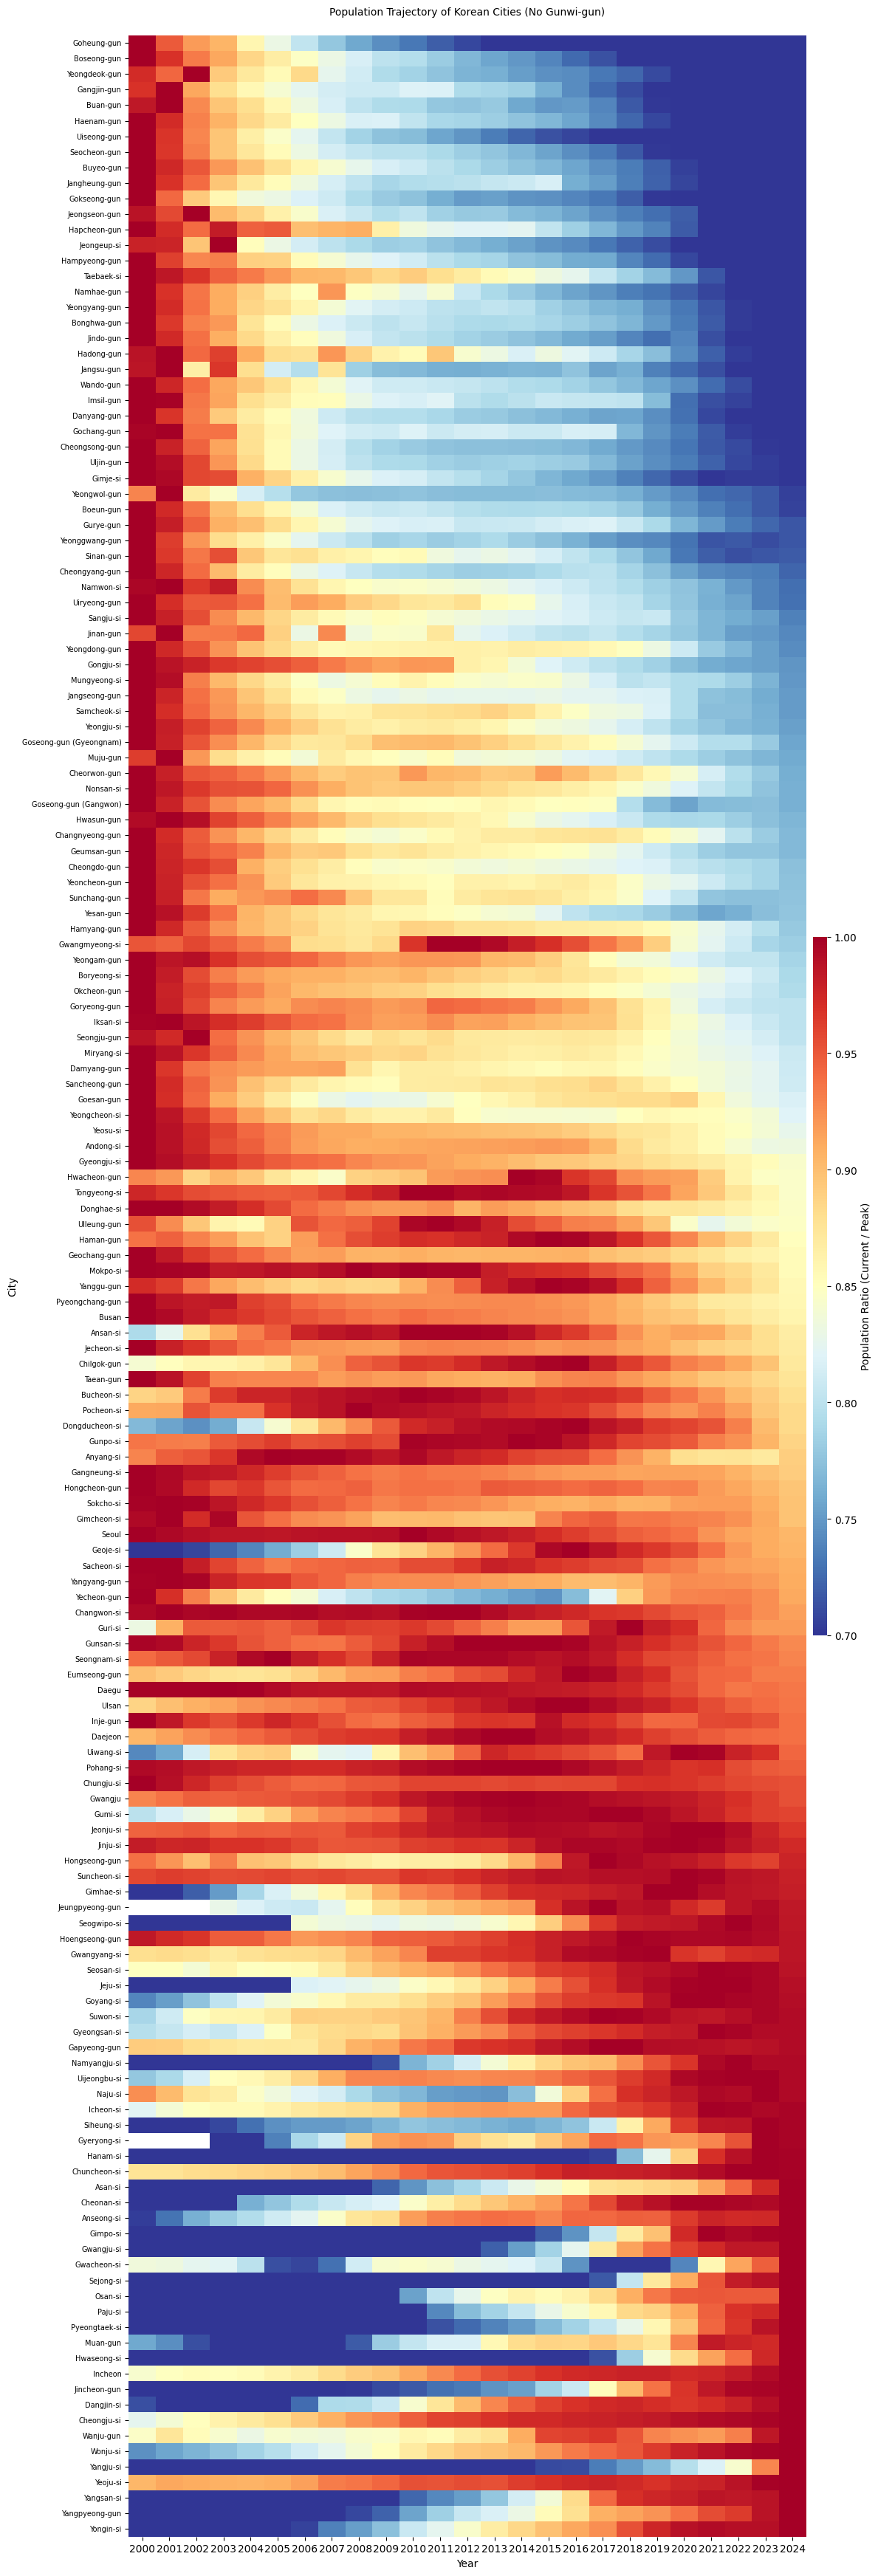

In [ ]:

# ========================================================
# [Step 3] Figure 1: 히트맵 (Heatmap) - 얇은 바 적용
# ========================================================
pivot_df = df_vis.pivot_table(index='city_name_Eng', columns='Year', values='Peak_Ratio')
last_year = pivot_df.columns[-1]
pivot_df = pivot_df.sort_values(by=last_year, ascending=True)

plt.figure(figsize=(12, 35))
sns.heatmap(
    pivot_df,
    cmap="RdYlBu_r",
    vmin=0.7, vmax=1.0,
    cbar_kws={
        'label': 'Population Ratio (Current / Peak)',
        'aspect': 50,     # 바를 얇게 (숫자가 클수록 얇음)
        'fraction': 0.02, # 차지하는 공간 비율 축소
        'pad': 0.01
    }
)
plt.title('Population Trajectory of Korean Cities (No Gunwi-gun)', fontsize=10, pad=20)
plt.xlabel('Year', fontsize=10)
plt.ylabel('City', fontsize=10)
plt.yticks(fontsize=7)
plt.tight_layout()

save_path1 = os.path.join(save_dir, 'Population_Trajectory_Heatmap_Final.jpg')
plt.savefig(save_path1, dpi=300, format='jpg', bbox_inches='tight')
print(f"1. 히트맵 저장 완료: {save_path1}")
plt.show()



/tmp/ipython-input-3302336435.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Year', y='Peak_Ratio', data=df_vis, palette="Blues")


2. 박스플롯 저장 완료: /content/drive/MyDrive/Urban Scaling/figures/Population_Ratio_Boxplot_Final.jpg


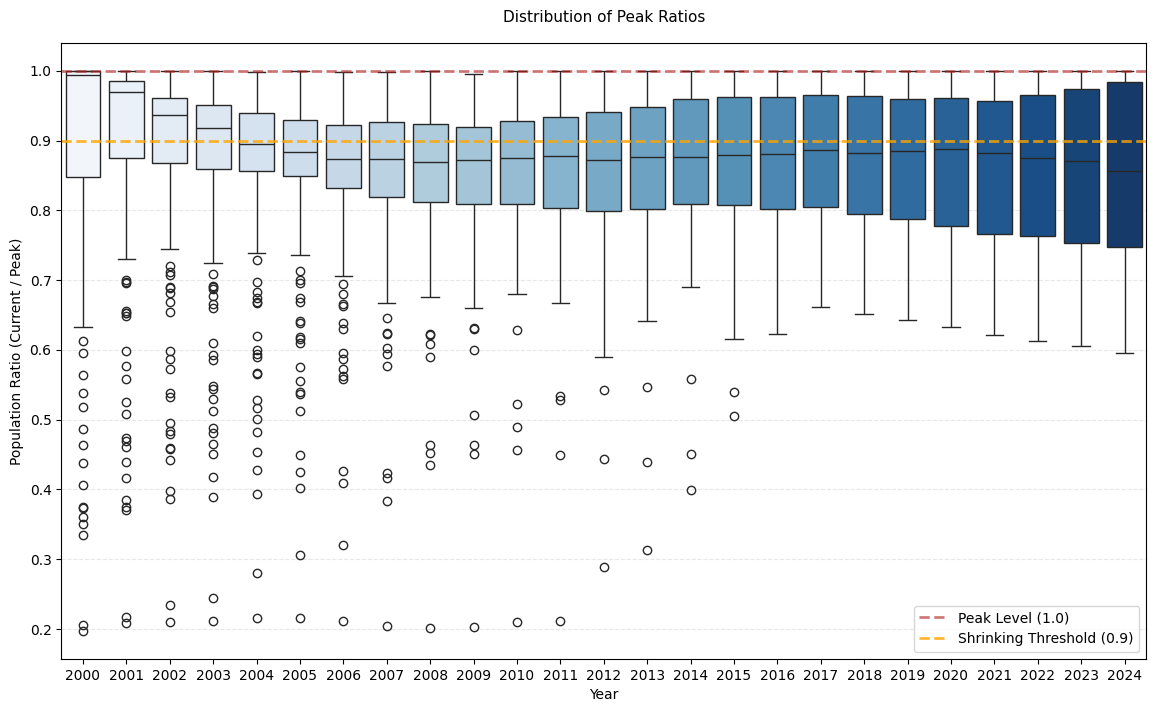

In [ ]:

# ========================================================
# [Step 4] Figure 2: 박스플롯 (Boxplot) - Legend 우하단
# ========================================================
plt.figure(figsize=(14, 8))
sns.boxplot(x='Year', y='Peak_Ratio', data=df_vis, palette="Blues")

plt.axhline(y=1.0, color='firebrick', linestyle='--', alpha=0.6, linewidth=2, label='Peak Level (1.0)')
plt.axhline(y=0.9, color='orange', linestyle='--', alpha=0.8, linewidth=2, label='Shrinking Threshold (0.9)')

plt.title('Distribution of Peak Ratios', fontsize=11, pad=15)
plt.xlabel('Year', fontsize=10)
plt.ylabel('Population Ratio (Current / Peak)', fontsize=10)
plt.legend(loc='lower right', fontsize=10) # 범례 위치 수정
plt.grid(axis='y', alpha=0.3, linestyle='--')

save_path2 = os.path.join(save_dir, 'Population_Ratio_Boxplot_Final.jpg')
plt.savefig(save_path2, dpi=300, format='jpg', bbox_inches='tight')
print(f"2. 박스플롯 저장 완료: {save_path2}")
plt.show()

<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-2255198219.py:13: SyntaxWarning: invalid escape sequence '\l'
  f"Scaling Law: $\ln Y = {intercept:.2f} + {slope:.3f} \ln N$\n"
/tmp/ipython-input-2255198219.py:13: SyntaxWarning: invalid escape sequence '\l'
  f"Scaling Law: $\ln Y = {intercept:.2f} + {slope:.3f} \ln N$\n"


3. 산점도 저장 완료: /content/drive/MyDrive/Urban Scaling/figures/Urban_Scaling_Suicide_Pooled_Final.jpg


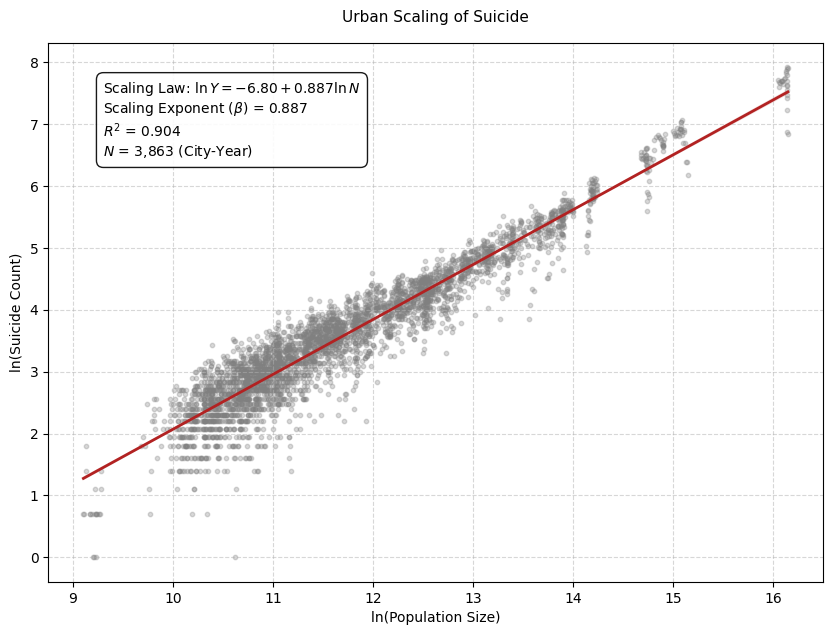

In [ ]:
# ========================================================
# [Step 5] Figure 3: 산점도 (Scatter Plot) - Scaling Law
# ========================================================
df_plot = df_final.dropna(subset=['Pop_Reg', 'Suicide_Count']).copy()
df_plot = df_plot[df_plot['Suicide_Count'] > 0] # 로그 변환 위해 0 제거
df_plot['ln_N'] = np.log(df_plot['Pop_Reg'])
df_plot['ln_Y'] = np.log(df_plot['Suicide_Count'])

# 회귀분석
slope, intercept, r_value, p_value, std_err = stats.linregress(df_plot['ln_N'], df_plot['ln_Y'])

stats_text = (
    f"Scaling Law: $\ln Y = {intercept:.2f} + {slope:.3f} \ln N$\n"
    f"Scaling Exponent ($\\beta$) = {slope:.3f}\n"
    f"$R^2$ = {r_value**2:.3f}\n"
    f"$N$ = {len(df_plot):,} (City-Year)"
)

plt.figure(figsize=(10, 7))
sns.regplot(
    x='ln_N', y='ln_Y', data=df_plot,
    scatter_kws={'alpha': 0.3, 'color': 'gray', 's': 10},
    line_kws={'color': 'firebrick', 'linewidth': 2}
)

# 텍스트 박스
text_x = df_plot['ln_N'].min() + 0.2
text_y = df_plot['ln_Y'].max() - 0.2
plt.text(
    text_x, text_y, stats_text, fontsize=10, color='black', verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black", alpha=0.9)
)

plt.title('Urban Scaling of Suicide', fontsize=11, pad=15)
plt.xlabel('ln(Population Size)', fontsize=10)
plt.ylabel('ln(Suicide Count)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

save_path3 = os.path.join(save_dir, 'Urban_Scaling_Suicide_Pooled_Final.jpg')
plt.savefig(save_path3, dpi=300, format='jpg', bbox_inches='tight')
print(f"3. 산점도 저장 완료: {save_path3}")
plt.show()

In [ ]:
# 2005년 기준 Ratio가 가장 낮은 도시(Outlier) 10곳 확인
year_check = 2005
df_outliers = df_vis[df_vis['Year'] == year_check].sort_values(by='Peak_Ratio', ascending=True).head(10)

print(f"=== {year_check}년 기준 Peak Ratio 하위 10개 도시 (Outlier 후보) ===")
print(df_outliers[['City_name_Kor', 'city_name_Eng', 'Pop_Reg', 'Pop_Peak', 'Peak_Ratio']])

=== 2005년 기준 Peak Ratio 하위 10개 도시 (Outlier 후보) ===
    City_name_Kor city_name_Eng   Pop_Reg  Pop_Peak  Peak_Ratio
818       세종특별자치시     Sejong-si   84308.0  390685.0    0.215795
842        경기도화성시   Hwaseong-si  296530.0  968821.0    0.306073
836        경기도하남시      Hanam-si  132850.0  329861.0    0.402745
841        경기도김포시      Gimpo-si  207229.0  486853.0    0.425650
971   제주특별자치도서귀포시   Seogwipo-si   83027.0  184770.0    0.449353
838        경기도파주시       Paju-si  261770.0  511308.0    0.511961
832        경기도오산시       Osan-si  129843.0  242065.0    0.536397
843        경기도광주시    Gwangju-si  214498.0  397605.0    0.539475
844        경기도양주시     Yangju-si  160589.0  289005.0    0.555662
882       충청남도아산시       Asan-si  204431.0  355014.0    0.575839


### 그룹별 Beta 비교 및 시각화

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import os

# ========================================================
# [Step 0] 저장 경로 및 데이터 준비
# ========================================================
save_dir = "/content/drive/MyDrive/Urban Scaling/figures"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 이전 단계에서 만든 군위군 제거 & 고성군 수정된 df_final 사용
# 만약 메모리에 없다면 직전 코드를 먼저 실행해주세요.
df_analysis = df_final.dropna(subset=['Pop_Reg', 'Suicide_Count']).copy()
df_analysis = df_analysis[df_analysis['Suicide_Count'] > 0] # 로그 변환용


In [ ]:

# ========================================================
# [Step 1] 도시 유형 분류 (Shrinking vs Growing)
# ========================================================
# 1. 도시별 2024년(또는 마지막 연도) Ratio 구하기
df_analysis['Pop_Peak'] = df_analysis.groupby('City_Code')['Pop_Reg'].transform('max')
# 각 도시의 마지막 연도 데이터만 추출하여 유형 판별
last_year_data = df_analysis.sort_values('Year').groupby('City_Code').tail(1)
last_year_data['Final_Ratio'] = last_year_data['Pop_Reg'] / last_year_data['Pop_Peak']

# 기준(Threshold): 0.9
threshold = 0.90
shrinking_cities = last_year_data[last_year_data['Final_Ratio'] < threshold]['City_Code'].unique()

# 2. 전체 데이터에 유형 매핑
df_analysis['City_Type'] = df_analysis['City_Code'].apply(
    lambda x: 'Shrinking City' if x in shrinking_cities else 'Growing/Stable City'
)

# 그룹별 도시 개수 확인
n_shrinking = len(shrinking_cities)
n_growing = df_analysis['City_Code'].nunique() - n_shrinking
print(f"=== 도시 유형 분류 결과 (Threshold: {threshold}) ===")
print(f"Shrinking Cities: {n_shrinking}개")
print(f"Growing/Stable Cities: {n_growing}개")



=== 도시 유형 분류 결과 (Threshold: 0.9) ===
Shrinking Cities: 94개
Growing/Stable Cities: 67개


In [ ]:
# ========================================================
# [Step 2] 그룹별 회귀분석 (Beta 계산)
# ========================================================
df_analysis['ln_N'] = np.log(df_analysis['Pop_Reg'])
df_analysis['ln_Y'] = np.log(df_analysis['Suicide_Count'])

results = {}

for c_type in ['Growing/Stable City', 'Shrinking City']:
    sub_df = df_analysis[df_analysis['City_Type'] == c_type]
    slope, intercept, r_value, p_value, std_err = stats.linregress(sub_df['ln_N'], sub_df['ln_Y'])
    results[c_type] = {'beta': slope, 'r2': r_value**2, 'n': len(sub_df)}

print("\n=== 그룹별 Scaling Exponent (Beta) 비교 ===")
for k, v in results.items():
    print(f"[{k}] Beta: {v['beta']:.3f} (R2: {v['r2']:.3f}, N: {v['n']})")



=== 그룹별 Scaling Exponent (Beta) 비교 ===
[Growing/Stable City] Beta: 0.902 (R2: 0.914, N: 1641)
[Shrinking City] Beta: 0.897 (R2: 0.831, N: 2222)


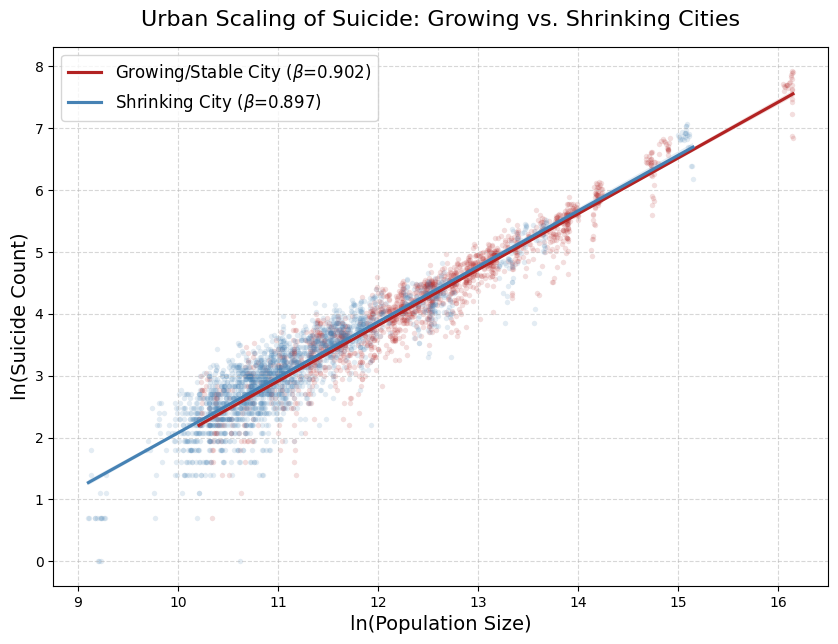

In [ ]:

# ========================================================
# [Step 3] 시각화 (Dual Scatter Plot)
# ========================================================
plt.figure(figsize=(10, 7))

# 색상 팔레트 설정 (Growing: 빨강/주황, Shrinking: 파랑/청록)
palette = {'Growing/Stable City': 'firebrick', 'Shrinking City': 'steelblue'}

# 산점도 및 회귀선 (lmplot 대신 regplot을 반복해서 그려서 커스텀 제어)
for c_type, color in palette.items():
    sub_df = df_analysis[df_analysis['City_Type'] == c_type]

    # 산점도 (연하게)
    sns.scatterplot(
        x='ln_N', y='ln_Y', data=sub_df,
        color=color, alpha=0.15, s=15, linewidth=0, label=None
    )

    # 회귀선 (진하게)
    sns.regplot(
        x='ln_N', y='ln_Y', data=sub_df,
        scatter=False, color=color, ci=95,
        label=f"{c_type} ($\\beta$={results[c_type]['beta']:.3f})"
    )

plt.title('Urban Scaling of Suicide: Growing vs. Shrinking Cities', fontsize=16, pad=15)
plt.xlabel('ln(Population Size)', fontsize=14)
plt.ylabel('ln(Suicide Count)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)



In [ ]:
# 저장
save_path = os.path.join(save_dir, 'Scaling_Comparison_Growing_vs_Shrinking.jpg')
plt.savefig(save_path, dpi=300, format='jpg', bbox_inches='tight')
print(f"\n이미지 저장 완료: {save_path}")

plt.show()


이미지 저장 완료: /content/drive/MyDrive/Urban Scaling/figures/Scaling_Comparison_Growing_vs_Shrinking.jpg


<Figure size 640x480 with 0 Axes>

In [ ]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# ========================================================
# [Step 1] 데이터 준비 (더미 변수 생성)
# ========================================================
# df_analysis가 메모리에 있다고 가정
df_reg = df_analysis.copy()

# 더미 변수 생성: Shrinking City = 1, Growing City = 0
df_reg['is_Shrinking'] = (df_analysis['City_Type'] == 'Shrinking City').astype(int)

# 교호작용 항(Interaction Term) 생성: ln_N * is_Shrinking
# 이 변수가 유의하면 '기울기'가 다른 것입니다.
df_reg['Interaction'] = df_reg['ln_N'] * df_reg['is_Shrinking']

# 독립변수(X) 설정: 상수항, 인구(ln_N), 쇠퇴여부(Dummy), 교호작용(Interaction)
X = df_reg[['ln_N', 'is_Shrinking', 'Interaction']]
X = sm.add_constant(X) # 상수항(Intercept) 추가
Y = df_reg['ln_Y']

# ========================================================
# [Step 2] 통계 모델 실행 (OLS Regression)
# ========================================================
model = sm.OLS(Y, X).fit()

# 결과 출력
print(model.summary())

# ========================================================
# [Step 3] 핵심 결과 해석 가이드 출력
# ========================================================
params = model.params
pvalues = model.pvalues

print("\n" + "="*50)
print("=== [핵심 결과 해석] ===")
print("="*50)

# 1. Baseline (Growing City)
print(f"1. Growing City (Baseline):")
print(f"   - Intercept (Alpha): {params['const']:.4f}")
print(f"   - Slope (Beta):      {params['ln_N']:.4f}")

# 2. Shrinking City Effect
print(f"\n2. Shrinking City Effect:")
diff_intercept = params['is_Shrinking']
diff_slope = params['Interaction']

print(f"   - Intercept Difference: {diff_intercept:+.4f} (p-value: {pvalues['is_Shrinking']:.4f})")
if pvalues['is_Shrinking'] < 0.05:
    print("     -> ★ 유의미함! 쇠퇴 도시의 자살률 자체가 구조적으로 높음/낮음.")
else:
    print("     -> 유의미하지 않음 (절편 차이 없음).")

print(f"   - Slope Difference:     {diff_slope:+.4f} (p-value: {pvalues['Interaction']:.4f})")
if pvalues['Interaction'] < 0.05:
    print("     -> ★ 유의미함! 쇠퇴 도시의 기울기가 통계적으로 다름.")
else:
    print("     -> 유의미하지 않음 (기울기는 통계적으로 같음).")

# 3. Final Model for Shrinking
final_intercept_shrink = params['const'] + params['is_Shrinking']
final_slope_shrink = params['ln_N'] + params['Interaction']

print(f"\n3. Summary:")
print(f"   - Growing City Line:   ln(Y) = {params['const']:.3f} + {params['ln_N']:.3f} * ln(N)")
print(f"   - Shrinking City Line: ln(Y) = {final_intercept_shrink:.3f} + {final_slope_shrink:.3f} * ln(N)")

                            OLS Regression Results                            
Dep. Variable:                   ln_Y   R-squared:                       0.905
Model:                            OLS   Adj. R-squared:                  0.905
Method:                 Least Squares   F-statistic:                 1.224e+04
Date:                Thu, 01 Jan 2026   Prob (F-statistic):               0.00
Time:                        08:32:08   Log-Likelihood:                -1363.7
No. Observations:                3863   AIC:                             2735.
Df Residuals:                    3859   BIC:                             2760.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -7.0143      0.093    -75.809   

=== 연도별 Scaling Exponent (Beta) 계산 결과 ===
Year   | Beta    | R2      | 95% CI
----------------------------------------
2000   | 0.8089  | 0.8277  | [0.751, 0.867]
2001   | 0.7973  | 0.8451  | [0.744, 0.851]
2002   | 0.8174  | 0.8912  | [0.773, 0.862]
2003   | 0.8559  | 0.8910  | [0.809, 0.902]
2004   | 0.8284  | 0.9187  | [0.790, 0.867]
2005   | 0.8594  | 0.9007  | [0.815, 0.904]
2006   | 0.8337  | 0.9002  | [0.791, 0.877]
2007   | 0.8396  | 0.9102  | [0.799, 0.881]
2008   | 0.8651  | 0.9079  | [0.822, 0.908]
2009   | 0.8519  | 0.9342  | [0.817, 0.887]
2010   | 0.8601  | 0.9349  | [0.825, 0.895]
2011   | 0.8688  | 0.9329  | [0.833, 0.905]
2012   | 0.8846  | 0.9300  | [0.847, 0.922]
2013   | 0.9001  | 0.9419  | [0.865, 0.935]
2014   | 0.9309  | 0.9323  | [0.892, 0.970]
2015   | 0.8992  | 0.9561  | [0.869, 0.929]
2016   | 0.9147  | 0.9400  | [0.879, 0.951]
2017   | 0.9260  | 0.9499  | [0.893, 0.959]
2018   | 0.9521  | 0.9616  | [0.922, 0.982]
2019   | 0.9416  | 0.9495  | [0.908, 0.975]
2

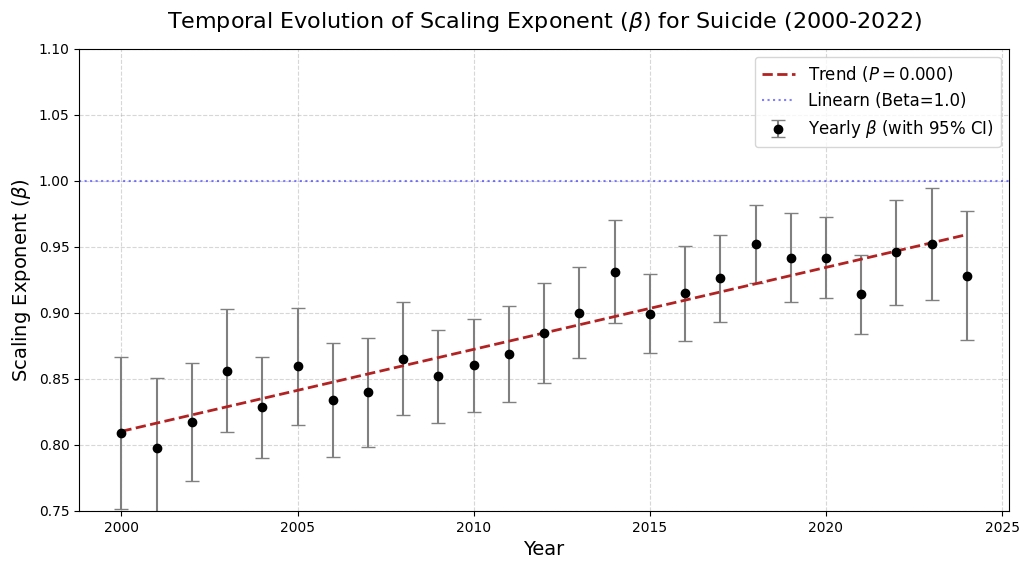

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import os

# ========================================================
# [Step 0] 저장 경로 및 데이터 준비
# ========================================================
save_dir = "/content/drive/MyDrive/Urban Scaling/figures"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 이전 단계의 df_final 사용 (군위군 제거, 고성군 수정 완료)
df_ts = df_final.dropna(subset=['Pop_Reg', 'Suicide_Count']).copy()
df_ts = df_ts[df_ts['Suicide_Count'] > 0] # 로그 변환용

# ========================================================
# [Step 1] 연도별 Beta 계산
# ========================================================
years = sorted(df_ts['Year'].unique())
beta_records = []

print(f"=== 연도별 Scaling Exponent (Beta) 계산 결과 ===")
print(f"{'Year':<6} | {'Beta':<7} | {'R2':<7} | {'95% CI'}")
print("-" * 40)

for year in years:
    # 해당 연도 데이터 추출
    sub_df = df_ts[df_ts['Year'] == year]

    # 로그 변환
    ln_N = np.log(sub_df['Pop_Reg'])
    ln_Y = np.log(sub_df['Suicide_Count'])

    # 회귀분석
    slope, intercept, r_value, p_value, std_err = stats.linregress(ln_N, ln_Y)

    # 95% 신뢰구간 계산 (1.96 * 표준오차)
    ci_margin = 1.96 * std_err

    # 기록
    beta_records.append({
        'Year': year,
        'Beta': slope,
        'Upper': slope + ci_margin,
        'Lower': slope - ci_margin,
        'R2': r_value**2,
        'StdErr': std_err
    })

    print(f"{year:<6} | {slope:.4f}  | {r_value**2:.4f}  | [{slope-ci_margin:.3f}, {slope+ci_margin:.3f}]")

# 데이터프레임 변환
df_beta = pd.DataFrame(beta_records)


# ========================================================
# [Step 2] Beta 값의 시간적 추세 (Trend) 검증
# ========================================================
# "Beta 자체가 시간이 지날수록 변하는가?"에 대한 메타 회귀분석
trend_slope, trend_intercept, trend_r, trend_p, trend_err = stats.linregress(df_beta['Year'], df_beta['Beta'])

print("\n" + "="*50)
print("=== [Theme 2 핵심 결과] Beta의 시계열 변화 ===")
print("="*50)
print(f"Trend Slope (d_Beta/dt): {trend_slope:.5f}")
print(f"P-value: {trend_p:.5f}")

if trend_p < 0.05:
    direction = "증가(상승)" if trend_slope > 0 else "감소(하락)"
    print(f"-> ★ 유의미함! Beta 값이 매년 {trend_slope:.5f} 씩 {direction}하고 있습니다.")
else:
    print("-> 유의미하지 않음 (Beta 값은 시간에 따라 일정함).")


# ========================================================
# [Step 3] 시각화 (Temporal Evolution of Beta)
# ========================================================
plt.figure(figsize=(12, 6))

# 1. Beta 값 (점) 및 신뢰구간 (에러바)
plt.errorbar(
    df_beta['Year'], df_beta['Beta'],
    yerr=1.96*df_beta['StdErr'],
    fmt='o', color='black', ecolor='gray', capsize=5, label='Yearly $\\beta$ (with 95% CI)'
)

# 2. 추세선 (Trend Line)
# 유의하든 안 하든 흐름을 보기 위해 그립니다.
line_x = np.array(years)
line_y = trend_intercept + trend_slope * line_x
plt.plot(line_x, line_y, color='firebrick', linewidth=2, linestyle='--', label=f'Trend ($P={trend_p:.3f}$)')

# 3. Super-linear vs Sub-linear 기준선
plt.axhline(y=1.0, color='blue', linestyle=':', alpha=0.5, label='Linearn (Beta=1.0)')

# 레이블 설정
plt.title('Temporal Evolution of Scaling Exponent ($\\beta$) for Suicide (2000-2022)', fontsize=16, pad=15)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Scaling Exponent ($\\beta$)', fontsize=14)
plt.ylim(0.75, 1.1) # Y축 범위 고정 (변화 잘 보이게)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# 저장
save_path = os.path.join(save_dir, 'Temporal_Evolution_of_Beta.jpg')
plt.savefig(save_path, dpi=300, format='jpg', bbox_inches='tight')

print(f"그래프 저장 완료: {save_path}")
plt.show()

=== 데이터 기간 확인 ===
분석 기간: 2000 ~ 2023년
데이터 개수: 3778행

=== 연도별 Scaling Exponent (Beta) 계산 결과 ===
Year   | Beta    | R2      | 95% CI
----------------------------------------
2000   | 0.8089  | 0.8277  | [0.751, 0.867]
2001   | 0.7973  | 0.8451  | [0.744, 0.851]
2002   | 0.8174  | 0.8912  | [0.773, 0.862]
2003   | 0.8559  | 0.8910  | [0.809, 0.902]
2004   | 0.8284  | 0.9187  | [0.790, 0.867]
2005   | 0.8594  | 0.9007  | [0.815, 0.904]
2006   | 0.8337  | 0.9002  | [0.791, 0.877]
2007   | 0.8396  | 0.9102  | [0.799, 0.881]
2008   | 0.8651  | 0.9079  | [0.822, 0.908]
2009   | 0.8519  | 0.9342  | [0.817, 0.887]
2010   | 0.8601  | 0.9349  | [0.825, 0.895]
2011   | 0.8688  | 0.9329  | [0.833, 0.905]
2012   | 0.8846  | 0.9300  | [0.847, 0.922]
2013   | 0.9001  | 0.9419  | [0.865, 0.935]
2014   | 0.9309  | 0.9323  | [0.892, 0.970]
2015   | 0.8992  | 0.9561  | [0.869, 0.929]
2016   | 0.9147  | 0.9400  | [0.879, 0.951]
2017   | 0.9260  | 0.9499  | [0.893, 0.959]
2018   | 0.9521  | 0.9616  | [0.922,

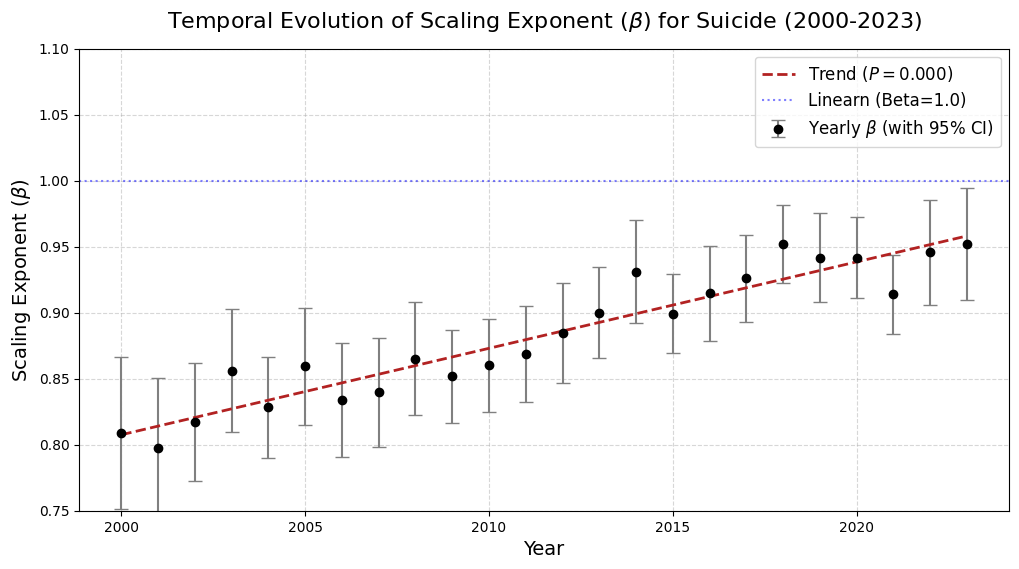

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import os

# ========================================================
# [Step 0] 저장 경로 및 데이터 준비
# ========================================================
save_dir = "/content/drive/MyDrive/Urban Scaling/figures"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 1. 결측치 제거 및 0보다 큰 값 추출
df_ts = df_final.dropna(subset=['Pop_Reg', 'Suicide_Count']).copy()
df_ts = df_ts[df_ts['Suicide_Count'] > 0] # 로그 변환용

# --------------------------------------------------------
# [수정된 부분] 2022년까지만 데이터 남기기 (Cut-off)
# --------------------------------------------------------
df_ts = df_ts[df_ts['Year'] <= 2023]

print(f"=== 데이터 기간 확인 ===")
print(f"분석 기간: {df_ts['Year'].min()} ~ {df_ts['Year'].max()}년")
print(f"데이터 개수: {len(df_ts)}행")

# ========================================================
# [Step 1] 연도별 Beta 계산
# ========================================================
years = sorted(df_ts['Year'].unique())
beta_records = []

print(f"\n=== 연도별 Scaling Exponent (Beta) 계산 결과 ===")
print(f"{'Year':<6} | {'Beta':<7} | {'R2':<7} | {'95% CI'}")
print("-" * 40)

for year in years:
    # 해당 연도 데이터 추출
    sub_df = df_ts[df_ts['Year'] == year]

    # 로그 변환
    ln_N = np.log(sub_df['Pop_Reg'])
    ln_Y = np.log(sub_df['Suicide_Count'])

    # 회귀분석
    slope, intercept, r_value, p_value, std_err = stats.linregress(ln_N, ln_Y)

    # 95% 신뢰구간 계산 (1.96 * 표준오차)
    ci_margin = 1.96 * std_err

    # 기록
    beta_records.append({
        'Year': year,
        'Beta': slope,
        'Upper': slope + ci_margin,
        'Lower': slope - ci_margin,
        'R2': r_value**2,
        'StdErr': std_err
    })

    print(f"{year:<6} | {slope:.4f}  | {r_value**2:.4f}  | [{slope-ci_margin:.3f}, {slope+ci_margin:.3f}]")

# 데이터프레임 변환
df_beta = pd.DataFrame(beta_records)


# ========================================================
# [Step 2] Beta 값의 시간적 추세 (Trend) 검증
# ========================================================
# "Beta 자체가 시간이 지날수록 변하는가?"에 대한 메타 회귀분석
trend_slope, trend_intercept, trend_r, trend_p, trend_err = stats.linregress(df_beta['Year'], df_beta['Beta'])

print("\n" + "="*50)
print("=== [Theme 2 핵심 결과] Beta의 시계열 변화 (2000-2023) ===")
print("="*50)
print(f"Trend Slope (d_Beta/dt): {trend_slope:.5f}")
print(f"P-value: {trend_p:.5f}")

if trend_p < 0.05:
    direction = "증가(상승)" if trend_slope > 0 else "감소(하락)"
    print(f"-> ★ 유의미함! Beta 값이 매년 {trend_slope:.5f} 씩 {direction}하고 있습니다.")
else:
    print("-> 유의미하지 않음 (Beta 값은 시간에 따라 일정함).")


# ========================================================
# [Step 3] 시각화 (Temporal Evolution of Beta)
# ========================================================
plt.figure(figsize=(12, 6))

# 1. Beta 값 (점) 및 신뢰구간 (에러바)
plt.errorbar(
    df_beta['Year'], df_beta['Beta'],
    yerr=1.96*df_beta['StdErr'],
    fmt='o', color='black', ecolor='gray', capsize=5, label='Yearly $\\beta$ (with 95% CI)'
)

# 2. 추세선 (Trend Line)
line_x = np.array(years)
line_y = trend_intercept + trend_slope * line_x
plt.plot(line_x, line_y, color='firebrick', linewidth=2, linestyle='--', label=f'Trend ($P={trend_p:.3f}$)')

# 3. Super-linear vs Sub-linear 기준선
plt.axhline(y=1.0, color='blue', linestyle=':', alpha=0.5, label='Linearn (Beta=1.0)')

# 레이블 설정
plt.title('Temporal Evolution of Scaling Exponent ($\\beta$) for Suicide (2000-2023)', fontsize=16, pad=15)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Scaling Exponent ($\\beta$)', fontsize=14)
plt.ylim(0.75, 1.1) # Y축 범위 고정
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# 저장
save_path = os.path.join(save_dir, 'Temporal_Evolution_of_Beta_2023Cutoff.jpg')
plt.savefig(save_path, dpi=300, format='jpg', bbox_inches='tight')

print(f"그래프 저장 완료: {save_path}")
plt.show()

## 연도별/그룹별 Beta 추이 비교

=== 연도별/그룹별 Beta 계산 진행 중... ===

=== [Trend Analysis] 그룹별 Beta 상승 속도 비교 ===
[Growing/Stable City]
 - Start Beta (2000 approx): 0.821
 - End Beta (2024 approx):   0.973
 - Change Rate (Slope):      0.00633 / year
 - P-value:                  0.00000
   -> ★ 유의미하게 증가 중
------------------------------
[Shrinking City]
 - Start Beta (2000 approx): 0.825
 - End Beta (2024 approx):   0.973
 - Change Rate (Slope):      0.00618 / year
 - P-value:                  0.00000
   -> ★ 유의미하게 증가 중
------------------------------
그래프 저장 완료: /content/drive/MyDrive/Urban Scaling/figures/Temporal_Evolution_by_Group.jpg


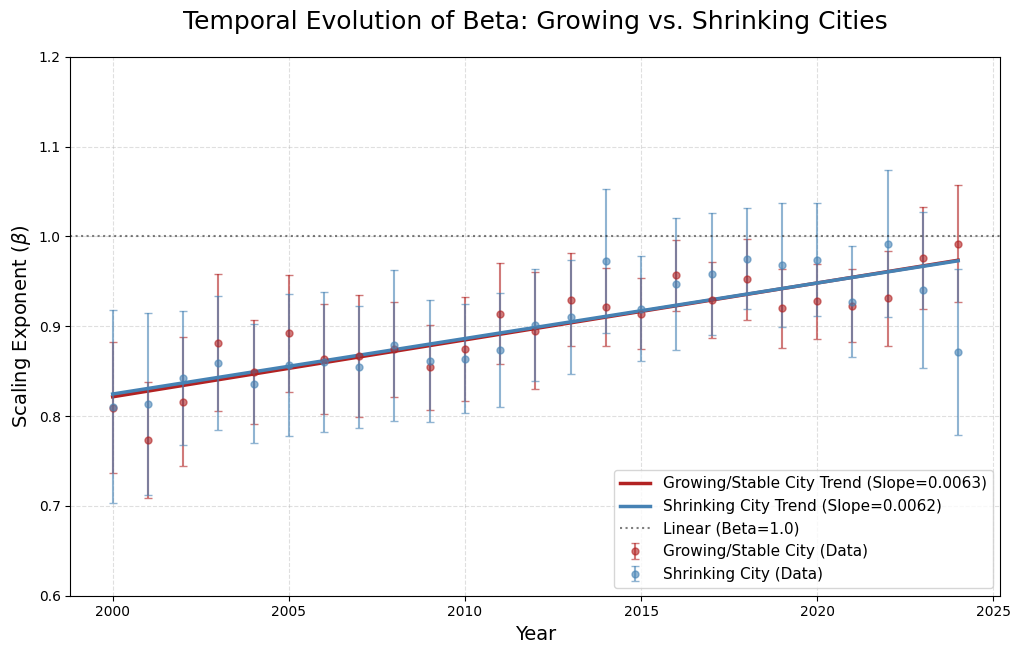

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import os

# ========================================================
# [Step 0] 저장 경로 및 데이터 준비
# ========================================================
save_dir = "/content/drive/MyDrive/Urban Scaling/figures"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 데이터 준비 (군위군 제거, 고성군 수정 완료된 df_final 사용)
df_ts_group = df_final.dropna(subset=['Pop_Reg', 'Suicide_Count']).copy()
df_ts_group = df_ts_group[df_ts_group['Suicide_Count'] > 0]

# ========================================================
# [Step 1] 도시 유형 분류 (Shrinking vs Growing)
# ========================================================
# 1. 도시별 Peak Ratio 계산 (2024년 기준)
df_ts_group['Pop_Peak'] = df_ts_group.groupby('City_Code')['Pop_Reg'].transform('max')

# 2. 각 도시의 마지막 연도 데이터만 추출하여 유형 판별
last_year_data = df_ts_group.sort_values('Year').groupby('City_Code').tail(1)
last_year_data['Final_Ratio'] = last_year_data['Pop_Reg'] / last_year_data['Pop_Peak']

# 3. 기준(Threshold): 0.9
threshold = 0.90
shrinking_cities = last_year_data[last_year_data['Final_Ratio'] < threshold]['City_Code'].unique()

# 4. 전체 데이터에 유형 매핑
df_ts_group['City_Type'] = df_ts_group['City_Code'].apply(
    lambda x: 'Shrinking City' if x in shrinking_cities else 'Growing/Stable City'
)

# ========================================================
# [Step 2] 연도별 + 그룹별 Beta 계산
# ========================================================
years = sorted(df_ts_group['Year'].unique())
beta_results = []

print(f"=== 연도별/그룹별 Beta 계산 진행 중... ===")

for year in years:
    for c_type in ['Growing/Stable City', 'Shrinking City']:
        # 해당 연도 & 해당 그룹 데이터 추출
        sub_df = df_ts_group[(df_ts_group['Year'] == year) & (df_ts_group['City_Type'] == c_type)]

        # 데이터가 충분한지 확인 (최소 10개 이상)
        if len(sub_df) < 10:
            continue

        ln_N = np.log(sub_df['Pop_Reg'])
        ln_Y = np.log(sub_df['Suicide_Count'])

        slope, intercept, r_value, p_value, std_err = stats.linregress(ln_N, ln_Y)

        beta_results.append({
            'Year': year,
            'City_Type': c_type,
            'Beta': slope,
            'StdErr': std_err,
            'R2': r_value**2
        })

df_beta_group = pd.DataFrame(beta_results)

# ========================================================
# [Step 3] 그룹별 Trend (기울기) 비교 분석
# ========================================================
print("\n" + "="*50)
print("=== [Trend Analysis] 그룹별 Beta 상승 속도 비교 ===")
print("="*50)

colors = {'Growing/Stable City': 'firebrick', 'Shrinking City': 'steelblue'}
trend_lines = {}

for c_type in ['Growing/Stable City', 'Shrinking City']:
    sub_data = df_beta_group[df_beta_group['City_Type'] == c_type]

    # Beta값에 대한 시계열 회귀 (d_Beta / dt)
    t_slope, t_intercept, t_r, t_p, t_err = stats.linregress(sub_data['Year'], sub_data['Beta'])

    trend_lines[c_type] = (t_slope, t_intercept) # 나중에 그리기 위해 저장

    print(f"[{c_type}]")
    print(f" - Start Beta (2000 approx): {t_intercept + t_slope*2000:.3f}")
    print(f" - End Beta (2024 approx):   {t_intercept + t_slope*2024:.3f}")
    print(f" - Change Rate (Slope):      {t_slope:.5f} / year")
    print(f" - P-value:                  {t_p:.5f}")
    if t_p < 0.05:
        print("   -> ★ 유의미하게 증가 중")
    else:
        print("   -> 유의미한 변화 없음")
    print("-" * 30)


# ========================================================
# [Step 4] 시각화 (Dual Trend Plot)
# ========================================================
plt.figure(figsize=(12, 7))

# 그룹별로 그리기
for c_type in ['Growing/Stable City', 'Shrinking City']:
    sub_data = df_beta_group[df_beta_group['City_Type'] == c_type]
    col = colors[c_type]

    # 1. 에러바가 있는 점선 그래프 (실제 데이터)
    plt.errorbar(
        sub_data['Year'], sub_data['Beta'],
        yerr=1.96*sub_data['StdErr'],
        fmt='o', color=col, alpha=0.6, capsize=3, markersize=5,
        label=f'{c_type} (Data)'
    )

    # 2. 추세선 (Trend Line) - 진하게
    t_slope, t_intercept = trend_lines[c_type]
    line_x = np.array(years)
    line_y = t_intercept + t_slope * line_x
    plt.plot(line_x, line_y, color=col, linewidth=2.5, linestyle='-',
             label=f'{c_type} Trend (Slope={t_slope:.4f})')

# 기준선 (Beta=1.0)
plt.axhline(y=1.0, color='black', linestyle=':', alpha=0.5, label='Linear (Beta=1.0)')

plt.title('Temporal Evolution of Beta: Growing vs. Shrinking Cities', fontsize=18, pad=20)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Scaling Exponent ($\\beta$)', fontsize=14)
plt.legend(fontsize=11, loc='lower right')
plt.ylim(0.6, 1.2) # 범위 조절 (필요시 수정)
plt.grid(True, linestyle='--', alpha=0.4)

# 저장
save_path = os.path.join(save_dir, 'Temporal_Evolution_by_Group.jpg')
plt.savefig(save_path, dpi=300, format='jpg', bbox_inches='tight')

print(f"그래프 저장 완료: {save_path}")
plt.show()

## 극단 그룹 분석

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import os

df_final = pd.read_csv("/content/drive/MyDrive/Urban Scaling/Master_Panel_Base_Cleaned.csv")


=== 데이터 기간 재설정 ===
분석 기간: 2000 ~ 2022년
총 데이터 수: 3693행

=== [2022년 기준] 극단 그룹 재설정 ===
1. Extreme Growth (Ratio >= 0.99): 38개 도시
2. Extreme Shrinkage (Ratio <= 0.85): 73개 도시

=== [Re-Run] 2022년 기준 Trend 분석 결과 ===
[Extreme Growth (Red Zone)]
 - Slope:   0.00453
 - P-value: 0.00455
   -> ★ 유의미하게 증가 중
[Extreme Shrinkage (Blue Zone)]
 - Slope:   0.00568
 - P-value: 0.00051
   -> ★ 유의미하게 증가 중

그래프 저장 완료: /content/drive/MyDrive/Urban Scaling/figures/Temporal_Evolution_Extreme_Groups_2022.jpg


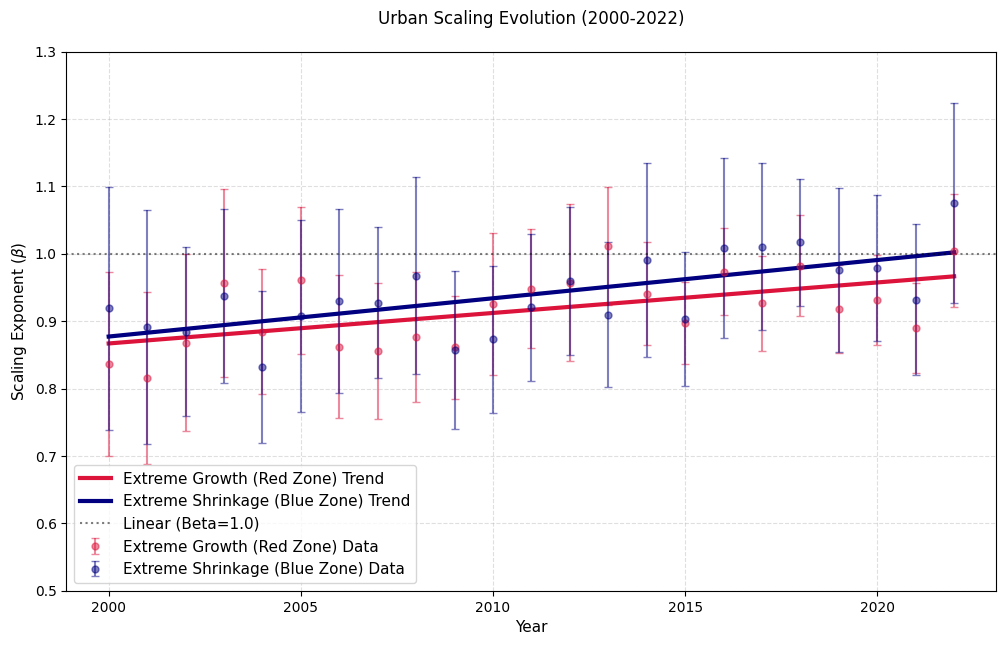

In [ ]:

# ========================================================
# [Step 0] 데이터 필터링 (2000 ~ 2022년만 사용)
# ========================================================
save_dir = "/content/drive/MyDrive/Urban Scaling/figures"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 2022년 이전 데이터만 추출
df_22 = df_final[df_final['Year'] <= 2022].dropna(subset=['Pop_Reg', 'Suicide_Count']).copy()
df_22 = df_22[df_22['Suicide_Count'] > 0]

print(f"=== 데이터 기간 재설정 ===")
print(f"분석 기간: {df_22['Year'].min()} ~ {df_22['Year'].max()}년")
print(f"총 데이터 수: {len(df_22)}행")

# ========================================================
# [Step 1] 극단 그룹 재정의 (2022년 기준)
# ========================================================
# 1. Peak & Ratio 다시 계산 (2022년까지만 봤을 때의 Peak)
df_22['Pop_Peak'] = df_22.groupby('City_Code')['Pop_Reg'].transform('max')

# 2. 각 도시의 마지막 연도(2022년) 데이터 추출
last_year_data = df_22.sort_values('Year').groupby('City_Code').tail(1)
last_year_data['Final_Ratio'] = last_year_data['Pop_Reg'] / last_year_data['Pop_Peak']

# 3. 임계값 설정 (동일하게 적용)
threshold_high = 0.99
threshold_low = 0.85

growing_codes = last_year_data[last_year_data['Final_Ratio'] >= threshold_high]['City_Code'].unique()
shrinking_codes = last_year_data[last_year_data['Final_Ratio'] <= threshold_low]['City_Code'].unique()

# 4. 그룹 매핑
def map_extreme_type(code):
    if code in growing_codes:
        return 'Extreme Growth (Red Zone)'
    elif code in shrinking_codes:
        return 'Extreme Shrinkage (Blue Zone)'
    else:
        return None

df_22['Group_Type'] = df_22['City_Code'].apply(map_extreme_type)
df_22_filtered = df_22.dropna(subset=['Group_Type']).copy()

# 그룹별 도시 수 확인
n_red = len(growing_codes)
n_blue = len(shrinking_codes)
print(f"\n=== [2022년 기준] 극단 그룹 재설정 ===")
print(f"1. Extreme Growth (Ratio >= {threshold_high}): {n_red}개 도시")
print(f"2. Extreme Shrinkage (Ratio <= {threshold_low}): {n_blue}개 도시")


# ========================================================
# [Step 2] 연도별 Beta 계산
# ========================================================
years = sorted(df_22_filtered['Year'].unique())
beta_results = []

for year in years:
    for g_type in ['Extreme Growth (Red Zone)', 'Extreme Shrinkage (Blue Zone)']:
        sub_df = df_22_filtered[(df_22_filtered['Year'] == year) & (df_22_filtered['Group_Type'] == g_type)]

        # 샘플 수 체크 (최소 7개 이상)
        if len(sub_df) < 7:
            continue

        ln_N = np.log(sub_df['Pop_Reg'])
        ln_Y = np.log(sub_df['Suicide_Count'])

        slope, intercept, r_value, p_value, std_err = stats.linregress(ln_N, ln_Y)

        beta_results.append({
            'Year': year,
            'Group_Type': g_type,
            'Beta': slope,
            'StdErr': std_err
        })

df_beta_22 = pd.DataFrame(beta_results)

# ========================================================
# [Step 3] Trend 분석 및 시각화
# ========================================================
plt.figure(figsize=(12, 7))
colors = {'Extreme Growth (Red Zone)': 'crimson', 'Extreme Shrinkage (Blue Zone)': 'navy'}

print("\n=== [Re-Run] 2022년 기준 Trend 분석 결과 ===")

for g_type in ['Extreme Growth (Red Zone)', 'Extreme Shrinkage (Blue Zone)']:
    sub_data = df_beta_22[df_beta_22['Group_Type'] == g_type]

    if sub_data.empty:
        print(f"[{g_type}] 데이터 부족")
        continue

    # Trend 회귀
    t_slope, t_intercept, t_r, t_p, t_err = stats.linregress(sub_data['Year'], sub_data['Beta'])

    print(f"[{g_type}]")
    print(f" - Slope:   {t_slope:.5f}")
    print(f" - P-value: {t_p:.5f}")

    if t_p < 0.05:
        print("   -> ★ 유의미하게 증가 중")
    else:
        print("   -> 유의미한 변화 없음")

    # 시각화
    col = colors[g_type]
    plt.errorbar(
        sub_data['Year'], sub_data['Beta'],
        yerr=1.96*sub_data['StdErr'],
        fmt='o', color=col, alpha=0.5, capsize=3, markersize=5,
        label=f'{g_type} Data'
    )

    line_x = np.array(years)
    line_y = t_intercept + t_slope * line_x
    plt.plot(line_x, line_y, color=col, linewidth=3, linestyle='-',
             label=f'{g_type} Trend')

plt.axhline(y=1.0, color='black', linestyle=':', alpha=0.5, label='Linear (Beta=1.0)')

plt.title('Urban Scaling Evolution (2000-2022)', fontsize=12, pad=20)
plt.xlabel('Year', fontsize=11)
plt.ylabel('Scaling Exponent ($\\beta$)', fontsize=11)
plt.legend(fontsize=11)
plt.ylim(0.5, 1.3)
plt.grid(True, linestyle='--', alpha=0.4)

save_path = os.path.join(save_dir, 'Temporal_Evolution_Extreme_Groups_2022.jpg')
plt.savefig(save_path, dpi=300, format='jpg', bbox_inches='tight')

print(f"\n그래프 저장 완료: {save_path}")
plt.show()

# 정제된 데이터 백업

In [ ]:
import os

# ========================================================
# [Checkpoint] 정제된 기본 데이터셋 저장
# ========================================================

# 1. 저장 경로 설정
save_dir = "/content/drive/MyDrive/Urban Scaling/"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 2. 파일명 설정 (알아보기 쉽게 구체적으로)
file_name = "Master_Panel_Base_Cleaned.csv"
save_path = os.path.join(save_dir, file_name)

# 3. CSV로 저장
# - index=False: 불필요한 인덱스 번호 저장 안 함
# - encoding='utf-8-sig': 엑셀에서 열었을 때 한글 안 깨지게 함
df_final.to_csv(save_path, index=False, encoding='utf-8-sig')

print(f"=== 데이터 저장 완료 ===")
print(f"파일 경로: {save_path}")
print(f"데이터 크기: {df_final.shape}")
print(f"포함된 연도: {df_final['Year'].min()} ~ {df_final['Year'].max()}")
print("주요 조치: 군위군 제거 완료, 고성군 이름 통합 완료")

=== 데이터 저장 완료 ===
파일 경로: /content/drive/MyDrive/Urban Scaling/Master_Panel_Base_Cleaned.csv
데이터 크기: (4025, 10)
포함된 연도: 2000 ~ 2024
주요 조치: 군위군 제거 완료, 고성군 이름 통합 완료


In [ ]:
df_final.head()

,Year,City_Code,province,city_name,City_name_Kor,city_name_Eng,Region_type,Pop_Reg,Suicide_Rate_100k,Suicide_Count
0,2000,11,서울특별시,서울,서울특별시,Seoul,SMA,10311314.0,9.1,938.0
1,2000,21,부산광역시,부산,부산광역시,Busan,Non-SMA,3796506.0,12.8,486.0
2,2000,22,대구광역시,대구,대구광역시,Daegu,Non-SMA,2524253.0,12.5,316.0
4,2000,23,인천광역시,인천,인천광역시,Incheon,SMA,2545769.0,14.0,356.0
5,2000,24,광주광역시,광주,광주광역시,Gwangju,Non-SMA,1371909.0,11.1,152.0


## stress rate merge

In [ ]:
import pandas as pd
import os
import re

# ========================================================
# [Step 1] 기준 데이터 준비
# ========================================================
# df_final이 메모리에 있다고 가정 (없으면 불러오기 코드 추가)
# df_final = pd.read_csv("/content/drive/MyDrive/Urban Scaling/Master_Panel_Base_Cleaned.csv")
df_master = df_final.copy()

# 기준 Key 컬럼 전처리 (문자열 변환 및 소수점 제거)
df_master['City_Code'] = df_master['City_Code'].astype(str).str.split('.').str[0]
df_master['Year'] = df_master['Year'].astype(int)

print(f"=== 병합 전 Master 데이터 크기: {df_master.shape} ===")


=== 병합 전 Master 데이터 크기: (4025, 10) ===


In [ ]:
# ========================================================
# [Step 2] 병합할 엑셀 파일 목록 설정
# ========================================================
data_path = "/content/drive/MyDrive/Urban Scaling/vars/"

# 리스트 형식: (파일명.xlsx, 엑셀안의_코드컬럼명, 만들고싶은_변수명)
# ※ 엑셀 파일 내에 'City_Code'라는 컬럼이 있다고 하셨으므로, 가운데 인자는 'City_Code'로 통일
files_to_merge = [
    # 파일명(.xlsx)                 엑셀파일_내_코드컬럼명      새로_만들_변수명
    ('Divorce_Data.xlsx',          'City_Code',              'Divorce_Rate'),
    # ('Stress_Data.xlsx',           'City_Code',              'Stress_Rate'),
    # ('Doctors_Data.xlsx',          'City_Code',              'Doctors_per_1k'),
    # ('Social_Facility.xlsx',       'City_Code',              'Social_Facility'),
    # ('Senior_Leisure.xlsx',        'City_Code',              'Leisure_per_1k_Senior'),
    # ('Fiscal_Data.xlsx',           'City_Code',              'Fiscal_Indep'),
    # ('GRDP_Data.xlsx',             'City_Code',              'GRDP_per_Capita'),
    # ('Elderly_Data.xlsx',          'City_Code',              'Elderly_Ratio'),
    # ('Single_Household.xlsx',      'City_Code',              'Single_Household'),
    # ('Migration_Data.xlsx',        'City_Code',              'Net_Migration_Rate'),
    # ('Housing_Data.xlsx',          'City_Code',              'Old_Housing_Ratio'),
]


In [ ]:
# ========================================================
# [Step 3] Melt & Merge 실행
# ========================================================
for file_name, code_col_name, new_var_name in files_to_merge:
    try:
        full_path = os.path.join(data_path, file_name)

        # 1. 엑셀 파일 읽기
        if not os.path.exists(full_path):
            print(f"[Skip] 파일 없음: {file_name}")
            continue

        print(f"Processing: {file_name}...")
        temp_df = pd.read_excel(full_path, engine='openpyxl')

        # 2. 필요한 컬럼만 선택 (City_Code + 연도 컬럼들)
        # 엑셀의 '시도', '시군', 'City_name_Kor' 등 불필요한 메타데이터 제거
        year_cols = [c for c in temp_df.columns if str(c).replace('년','').strip().isdigit()]

        if code_col_name not in temp_df.columns:
             print(f"[Error] '{code_col_name}' 컬럼이 엑셀 파일에 없습니다.")
             continue

        # 코드 컬럼 + 연도 컬럼만 남김
        cols_to_keep = [code_col_name] + year_cols
        temp_df = temp_df[cols_to_keep]

        # 3. Melt (Wide -> Long 변환)
        melted_df = temp_df.melt(id_vars=[code_col_name], var_name='Year', value_name=new_var_name)

        # 4. 데이터 전처리
        # 4-1. City_Code 정리
        melted_df['City_Code'] = melted_df[code_col_name].astype(str).str.split('.').str[0]

        # 4-2. Year 정리 (숫자만 남기기)
        melted_df['Year'] = melted_df['Year'].astype(str).str.replace(r'\D', '', regex=True)
        melted_df = melted_df[melted_df['Year'] != '']
        melted_df['Year'] = melted_df['Year'].astype(int)

        # 4-3. 값(Value) 정리 (숫자로 변환)
        melted_df[new_var_name] = pd.to_numeric(melted_df[new_var_name], errors='coerce')

        # 병합용 깔끔한 데이터프레임 완성
        melted_df = melted_df[['City_Code', 'Year', new_var_name]]

        # 5. 병합 (Left Merge)
        # df_master 기준으로 붙임
        df_master = pd.merge(df_master, melted_df, on=['City_Code', 'Year'], how='left')

        # 결과 확인
        na_count = df_master[new_var_name].isnull().sum()
        print(f"[Success] '{new_var_name}' 병합 완료! (전체 결측치 수: {na_count})")

    except Exception as e:
        print(f"[Fail] {file_name} 처리 중 오류 발생: {e}")

Processing: Divorce_Data.xlsx...
[Success] 'Divorce_Rate' 병합 완료! (전체 결측치 수: 0)


In [ ]:
# ========================================================
# [Step 3.5] 이혼 건수(Divorce_Count) 계산 (New!)
# ========================================================
print("\n=== 이혼 건수(Count) 계산 중... ===")

# 공식: (조이혼율 * 인구수) / 1000
# Pop_Reg가 있는지 확인 후 계산
if 'Pop_Reg' in df_master.columns and 'Divorce_Rate' in df_master.columns:
    df_master['Divorce_Count'] = (df_master['Divorce_Rate'] * df_master['Pop_Reg']) / 1000

    # 건수는 정수여야 하므로 반올림(round) 후 소수점 제거
    # 결측치(NaN)가 있으면 에러가 날 수 있으므로 fillna 없이 그대로 두고 연산
    # (나중에 분석할 때 dropna를 할 예정)
    print(f"-> Divorce_Count 컬럼 생성 완료.")
    print(f"-> 예시:\n{df_master[['City_name_Kor', 'Year', 'Pop_Reg', 'Divorce_Rate', 'Divorce_Count']].head(3)}")
else:
    print("[Warning] 'Pop_Reg' 또는 'Divorce_Rate' 컬럼이 없어 계산할 수 없습니다.")

# ========================================================
# [Step 4] 최종 확인 및 저장
# ========================================================
print("\n" + "="*50)
print(f"=== 최종 데이터 크기: {df_master.shape} ===")
print("=== 컬럼 목록 ===")
print(df_master.columns.tolist())

# 저장
save_path = os.path.join("/content/drive/MyDrive/Urban Scaling/", "Master_Panel_With_Divorce.csv")
df_master.to_csv(save_path, index=False, encoding='utf-8-sig')
print(f"저장 완료: {save_path}")


=== 이혼 건수(Count) 계산 중... ===
-> Divorce_Count 컬럼 생성 완료.
-> 예시:
  City_name_Kor  Year     Pop_Reg  Divorce_Rate  Divorce_Count
0         서울특별시  2000  10311314.0           2.5     25778.2850
1         부산광역시  2000   3796506.0           2.7     10250.5662
2         대구광역시  2000   2524253.0           2.1      5300.9313

=== 최종 데이터 크기: (4025, 12) ===
=== 컬럼 목록 ===
['Year', 'City_Code', 'province', 'city_name', 'City_name_Kor', 'city_name_Eng', 'Region_type', 'Pop_Reg', 'Suicide_Rate_100k', 'Suicide_Count', 'Divorce_Rate', 'Divorce_Count']
저장 완료: /content/drive/MyDrive/Urban Scaling/Master_Panel_With_Divorce.csv


In [ ]:
df_master.head()

,Year,City_Code,province,city_name,City_name_Kor,city_name_Eng,Region_type,Pop_Reg,Suicide_Rate_100k,Suicide_Count,Divorce_Rate,Divorce_Count
0,2000,11,서울특별시,서울,서울특별시,Seoul,SMA,10311314.0,9.1,938.0,2.5,25778.2850
1,2000,21,부산광역시,부산,부산광역시,Busan,Non-SMA,3796506.0,12.8,486.0,2.7,10250.5662
2,2000,22,대구광역시,대구,대구광역시,Daegu,Non-SMA,2524253.0,12.5,316.0,2.1,5300.9313
3,2000,23,인천광역시,인천,인천광역시,Incheon,SMA,2545769.0,14.0,356.0,3.1,7891.8839
4,2000,24,광주광역시,광주,광주광역시,Gwangju,Non-SMA,1371909.0,11.1,152.0,2.2,3018.1998


## Divorce Scaling 분석

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import os

# ========================================================
# [Step 1] 데이터 로드 및 전처리
# ========================================================
# 방금 저장한 Divorce 포함 데이터 불러오기
load_path = "/content/drive/MyDrive/Urban Scaling/Master_Panel_With_Divorce.csv"
save_dir = "/content/drive/MyDrive/Urban Scaling/figures"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

if os.path.exists(load_path):
    df_divorce = pd.read_csv(load_path)
    # City_Code 문자열 처리 (혹시 모를 오류 방지)
    df_divorce['City_Code'] = df_divorce['City_Code'].astype(str).str.split('.').str[0]
else:
    print("[Error] 데이터 파일이 없습니다. 이전 단계(병합)를 먼저 실행해주세요.")
    # (테스트를 위해 메모리에 있는 df_master가 있다면 사용)
    # df_divorce = df_master.copy()

# 분석용 데이터: 인구와 이혼 건수가 모두 0보다 큰 데이터만 추출 (로그 변환 위해)
df_anal = df_divorce.dropna(subset=['Pop_Reg', 'Divorce_Count']).copy()
df_anal = df_anal[(df_anal['Pop_Reg'] > 0) & (df_anal['Divorce_Count'] > 0)]

print(f"=== 분석 대상 데이터: {len(df_anal)} (City-Year observations) ===")


# ========================================================
# [Step 2] Pooled Scaling Exponent (전체 통합 Beta)
# ========================================================
# OLS Regression: ln(Divorce) ~ ln(Population)
ln_N = np.log(df_anal['Pop_Reg'])
ln_Y = np.log(df_anal['Divorce_Count'])

slope, intercept, r_val, p_val, std_err = stats.linregress(ln_N, ln_Y)

print("\n" + "="*50)
print(f"=== [Result 1] Pooled Scaling Exponent (Beta) for Divorce ===")
print("="*50)
print(f"Scaling Law: ln(Y) = {intercept:.2f} + {slope:.3f} * ln(N)")
print(f"Beta (Slope): {slope:.4f}")
print(f"R-squared:    {r_val**2:.4f}")
print(f"P-value:      {p_val:.4e}")

print(f"-> 해석: ", end="")
if slope > 1.05:
    print("Super-linear (도시가 클수록 인구 비례보다 '더 많이' 이혼함)")
elif slope < 0.95:
    print("Sub-linear (도시가 클수록 인구 비례보다 '더 적게' 이혼함)")
else:
    print("Linear (이혼 건수는 인구수에 정확히 비례함)")



=== 분석 대상 데이터: 4019 (City-Year observations) ===

=== [Result 1] Pooled Scaling Exponent (Beta) for Divorce ===
Scaling Law: ln(Y) = -6.61 + 1.042 * ln(N)
Beta (Slope): 1.0422
R-squared:    0.9719
P-value:      0.0000e+00
-> 해석: Linear (이혼 건수는 인구수에 정확히 비례함)


In [ ]:

# ========================================================
# [Step 3] Yearly Scaling Exponent (연도별 Beta 추이)
# ========================================================
years = sorted(df_anal['Year'].unique())
beta_records = []

for year in years:
    sub = df_anal[df_anal['Year'] == year]

    # 샘플 수가 너무 적으면 생략 (최소 10개)
    if len(sub) < 10:
        continue

    # 해당 연도 회귀분석
    s, i, r, p, err = stats.linregress(np.log(sub['Pop_Reg']), np.log(sub['Divorce_Count']))

    # 95% 신뢰구간 계산
    beta_records.append({
        'Year': year,
        'Beta': s,
        'Upper': s + 1.96 * err,
        'Lower': s - 1.96 * err,
        'R2': r**2
    })

df_beta_divorce = pd.DataFrame(beta_records)

# Beta값의 시간적 추세(Trend) 확인
t_slope, t_int, t_r, t_p, t_err = stats.linregress(df_beta_divorce['Year'], df_beta_divorce['Beta'])

print("\n" + "="*50)
print(f"=== [Result 2] Temporal Trend of Beta ===")
print("="*50)
print(f"Trend Slope (Change per Year): {t_slope:.5f}")
print(f"P-value: {t_p:.5f}")
if t_p < 0.05:
    direction = "증가(상승)" if t_slope > 0 else "감소(하락)"
    print(f"-> ★ 유의미함! 이혼율의 도시 집중도가 매년 {direction}하고 있습니다.")
else:
    print("-> 유의미하지 않음 (시간에 따른 변화 없음)")




=== [Result 2] Temporal Trend of Beta ===
Trend Slope (Change per Year): -0.00690
P-value: 0.00000
-> ★ 유의미함! 이혼율의 도시 집중도가 매년 감소(하락)하고 있습니다.



그래프 저장 완료: /content/drive/MyDrive/Urban Scaling/figures/Urban_Scaling_Divorce_Analysis.jpg


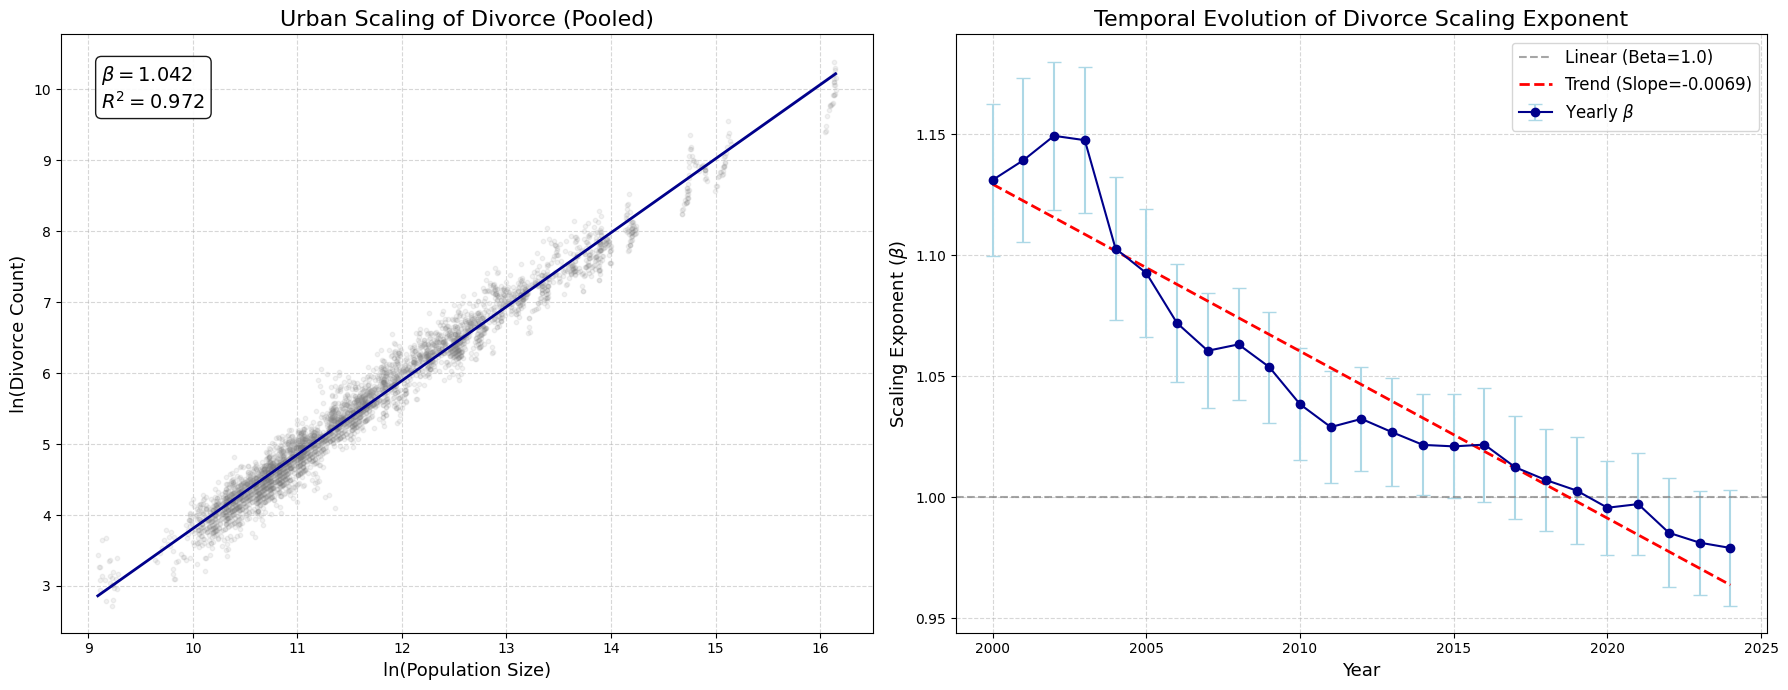

In [ ]:

# ========================================================
# [Step 4] 시각화 (Dual Plot)
# ========================================================
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# (왼쪽) Pooled Scatter Plot
# 전체 데이터를 한 번에 찍어서 전체적인 경향성을 보여줌
sns.regplot(
    x=ln_N, y=ln_Y,
    ax=ax[0],
    scatter_kws={'alpha': 0.1, 's': 10, 'color': 'gray'},
    line_kws={'color': 'darkblue', 'linewidth': 2}
)
stats_text = f"$\\beta = {slope:.3f}$\n$R^2 = {r_val**2:.3f}$"
ax[0].text(0.05, 0.95, stats_text, transform=ax[0].transAxes,
           fontsize=14, verticalalignment='top', bbox=dict(boxstyle="round", fc="white", alpha=0.9))

ax[0].set_title('Urban Scaling of Divorce (Pooled)', fontsize=16)
ax[0].set_xlabel('ln(Population Size)', fontsize=13)
ax[0].set_ylabel('ln(Divorce Count)', fontsize=13)
ax[0].grid(True, linestyle='--', alpha=0.5)

# (오른쪽) Temporal Evolution of Beta
# 연도별 Beta 변화와 추세선
ax[1].errorbar(
    df_beta_divorce['Year'], df_beta_divorce['Beta'],
    yerr=(df_beta_divorce['Upper'] - df_beta_divorce['Beta']),
    fmt='-o', color='darkblue', ecolor='lightblue', capsize=5, label='Yearly $\\beta$'
)

# 기준선 (Beta=1)
ax[1].axhline(y=1.0, color='gray', linestyle='--', alpha=0.7, label='Linear (Beta=1.0)')

# 추세선 그리기
line_x = df_beta_divorce['Year']
line_y = t_int + t_slope * line_x
ax[1].plot(line_x, line_y, color='red', linestyle='--', linewidth=2, label=f'Trend (Slope={t_slope:.4f})')

ax[1].set_title('Temporal Evolution of Divorce Scaling Exponent', fontsize=16)
ax[1].set_xlabel('Year', fontsize=13)
ax[1].set_ylabel('Scaling Exponent ($\\beta$)', fontsize=13)
ax[1].legend(fontsize=12)
ax[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

# 저장
save_path_img = os.path.join(save_dir, 'Urban_Scaling_Divorce_Analysis.jpg')
plt.savefig(save_path_img, dpi=300, format='jpg', bbox_inches='tight')
print(f"\n그래프 저장 완료: {save_path_img}")

plt.show()

<>:47: SyntaxWarning: invalid escape sequence '\l'
<>:47: SyntaxWarning: invalid escape sequence '\l'
<>:47: SyntaxWarning: invalid escape sequence '\l'
<>:47: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-3134351725.py:47: SyntaxWarning: invalid escape sequence '\l'
  f"Scaling Law: $\ln Y = {intercept:.2f} + {slope:.3f} \ln N$\n"
/tmp/ipython-input-3134351725.py:47: SyntaxWarning: invalid escape sequence '\l'
  f"Scaling Law: $\ln Y = {intercept:.2f} + {slope:.3f} \ln N$\n"


그래프 저장 완료: /content/drive/MyDrive/Urban Scaling/figures/Urban_Scaling_Divorce_Analysis_With_Eq.jpg


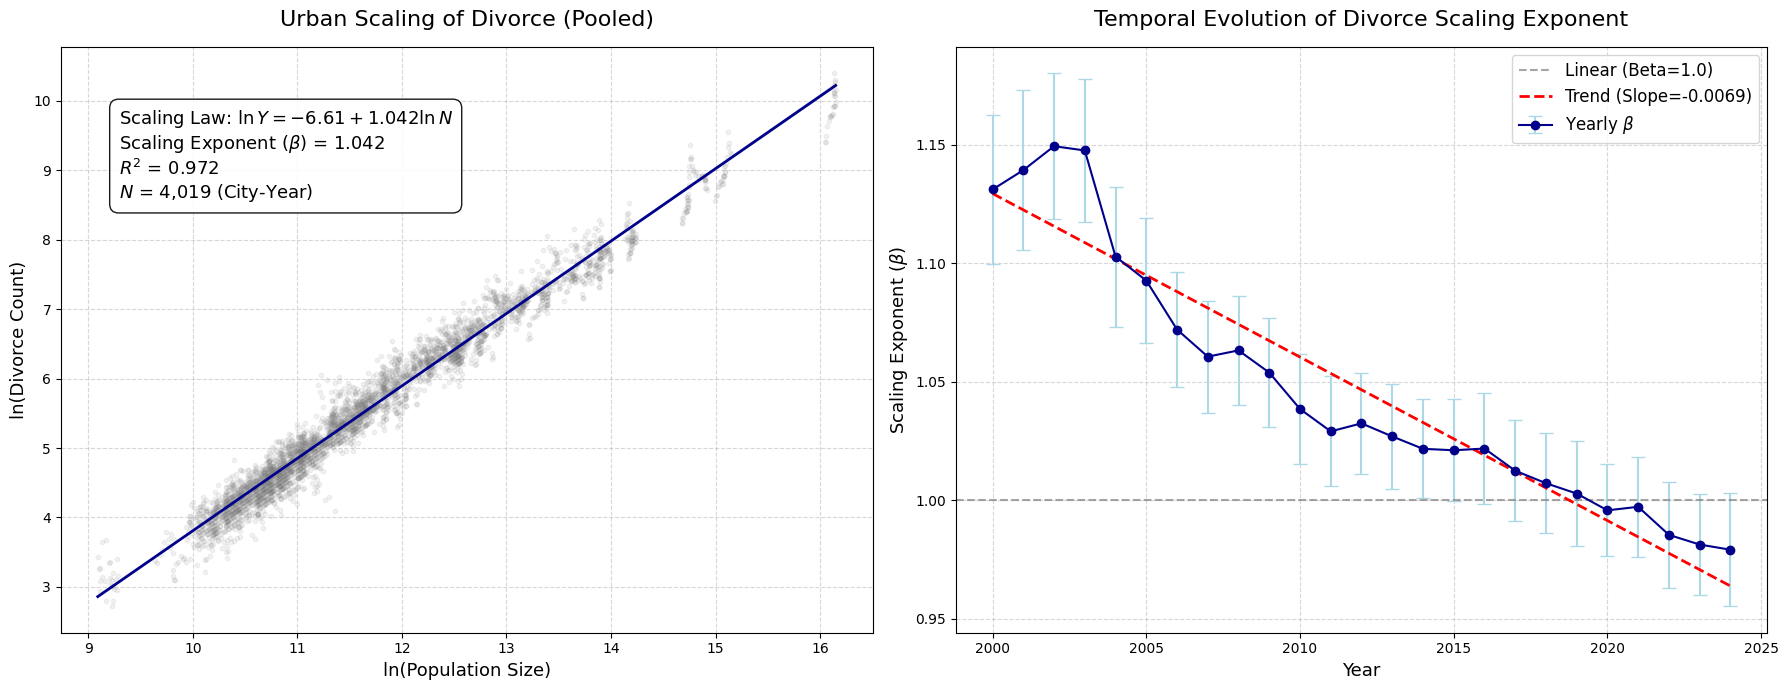

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import os

# ========================================================
# [Step 4] 시각화 (방정식 텍스트 추가 버전)
# ========================================================
# 데이터 준비 (df_divorce가 메모리에 있다고 가정)
# 만약 없다면: df_divorce = pd.read_csv("/content/drive/MyDrive/Urban Scaling/Master_Panel_With_Divorce.csv")

# 결측치 제거
df_anal = df_divorce.dropna(subset=['Pop_Reg', 'Divorce_Count']).copy()
df_anal = df_anal[(df_anal['Pop_Reg'] > 0) & (df_anal['Divorce_Count'] > 0)]

# 전체(Pooled) 회귀분석 다시 수행 (텍스트용)
ln_N = np.log(df_anal['Pop_Reg'])
ln_Y = np.log(df_anal['Divorce_Count'])
slope, intercept, r_val, p_val, std_err = stats.linregress(ln_N, ln_Y)

# 연도별 추이 분석 (오른쪽 그래프용)
years = sorted(df_anal['Year'].unique())
beta_records = []
for year in years:
    sub = df_anal[df_anal['Year'] == year]
    if len(sub) < 10: continue
    s, i, r, p, err = stats.linregress(np.log(sub['Pop_Reg']), np.log(sub['Divorce_Count']))
    beta_records.append({'Year': year, 'Beta': s, 'Upper': s + 1.96*err, 'Lower': s - 1.96*err})
df_beta_divorce = pd.DataFrame(beta_records)

# -------------------------------------------------------
# 그래프 그리기
# -------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# (왼쪽) Pooled Scatter Plot
sns.regplot(
    x=ln_N, y=ln_Y,
    ax=ax[0],
    scatter_kws={'alpha': 0.1, 's': 10, 'color': 'gray'},
    line_kws={'color': 'darkblue', 'linewidth': 2}
)

# [수정됨] 상세 통계 텍스트 박스 생성
stats_text = (
    f"Scaling Law: $\ln Y = {intercept:.2f} + {slope:.3f} \ln N$\n"
    f"Scaling Exponent ($\\beta$) = {slope:.3f}\n"
    f"$R^2$ = {r_val**2:.3f}\n"
    f"$N$ = {len(df_anal):,} (City-Year)"
)

# 텍스트 박스 위치 (좌측 상단)
text_x = ln_N.min() + 0.2
text_y = ln_Y.max() - 0.5
ax[0].text(
    text_x, text_y, stats_text,
    fontsize=13, color='black', verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black", alpha=0.9)
)

ax[0].set_title('Urban Scaling of Divorce (Pooled)', fontsize=16, pad=15)
ax[0].set_xlabel('ln(Population Size)', fontsize=13)
ax[0].set_ylabel('ln(Divorce Count)', fontsize=13)
ax[0].grid(True, linestyle='--', alpha=0.5)


# (오른쪽) Temporal Evolution of Beta
t_slope, t_int, t_r, t_p, t_err = stats.linregress(df_beta_divorce['Year'], df_beta_divorce['Beta'])

ax[1].errorbar(
    df_beta_divorce['Year'], df_beta_divorce['Beta'],
    yerr=(df_beta_divorce['Upper'] - df_beta_divorce['Beta']),
    fmt='-o', color='darkblue', ecolor='lightblue', capsize=5, label='Yearly $\\beta$'
)

# 기준선 및 추세선
ax[1].axhline(y=1.0, color='gray', linestyle='--', alpha=0.7, label='Linear (Beta=1.0)')
line_x = df_beta_divorce['Year']
line_y = t_int + t_slope * line_x
ax[1].plot(line_x, line_y, color='red', linestyle='--', linewidth=2, label=f'Trend (Slope={t_slope:.4f})')

ax[1].set_title('Temporal Evolution of Divorce Scaling Exponent', fontsize=16, pad=15)
ax[1].set_xlabel('Year', fontsize=13)
ax[1].set_ylabel('Scaling Exponent ($\\beta$)', fontsize=13)
ax[1].legend(fontsize=12)
ax[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

# 저장
save_dir = "/content/drive/MyDrive/Urban Scaling/figures"
if not os.path.exists(save_dir): os.makedirs(save_dir)
save_path_img = os.path.join(save_dir, 'Urban_Scaling_Divorce_Analysis_With_Eq.jpg')
plt.savefig(save_path_img, dpi=300, format='jpg', bbox_inches='tight')

print(f"그래프 저장 완료: {save_path_img}")
plt.show()

## suicide scaling yearly

=== Regression Stats for Plot ===
Year 2000: Beta = 0.809, R2 = 0.828
Year 2024: Beta = 0.928, R2 = 0.944

Graph saved to: /content/drive/MyDrive/Urban Scaling/figures/Suicide_Scaling_All_Years_Overlay.jpg


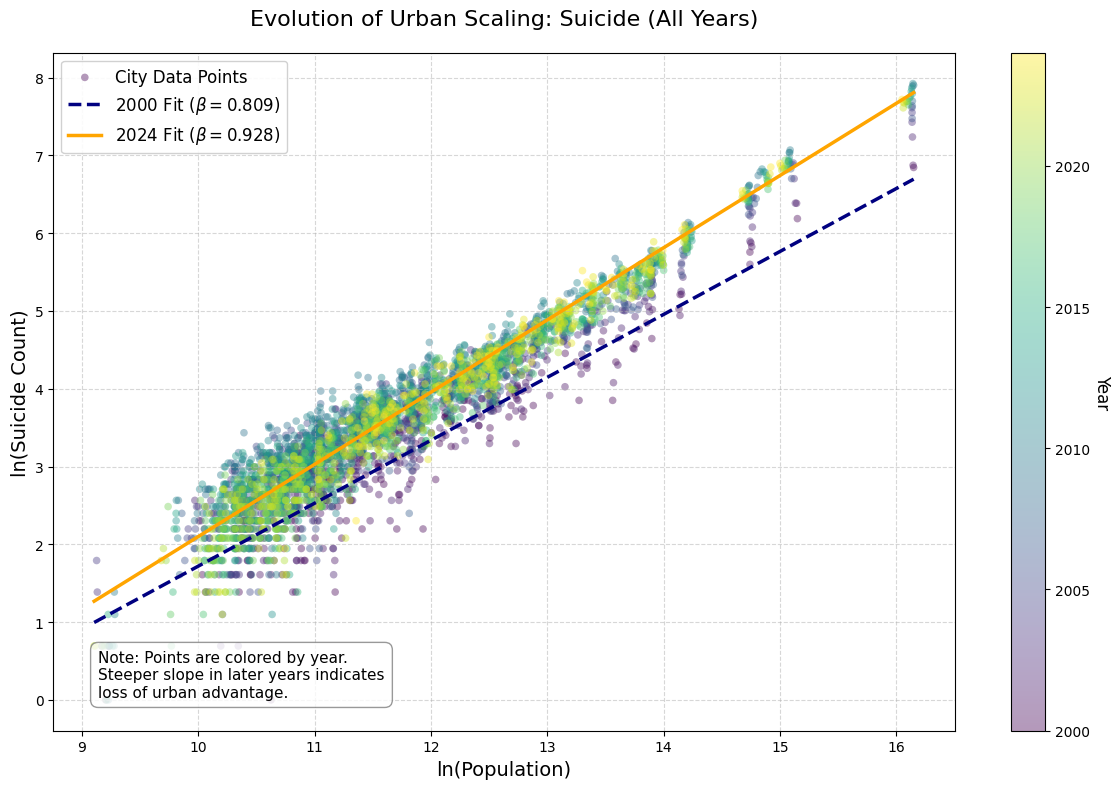

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import os

# ========================================================
# [Step 1] Data Preparation
# ========================================================
# Assuming df_final is in memory. If not, load your latest file:
df_final = pd.read_csv("/content/drive/MyDrive/Urban Scaling/Master_Panel_With_Divorce.csv")

# Create a working copy for analysis
df_plot = df_final.dropna(subset=['Pop_Reg', 'Suicide_Count', 'Year']).copy()
df_plot = df_plot[(df_plot['Pop_Reg'] > 0) & (df_plot['Suicide_Count'] > 0)]

# Log-transform variables
df_plot['ln_Pop'] = np.log(df_plot['Pop_Reg'])
df_plot['ln_Suicide'] = np.log(df_plot['Suicide_Count'])

# Get min and max years for labeling
min_year = df_plot['Year'].min()
max_year = df_plot['Year'].max()

# ========================================================
# [Step 2] Visualization
# ========================================================
fig, ax = plt.subplots(figsize=(12, 8))

# 1. Scatter Plot with Color Gradient (All years)
# c=Year maps the color to the year, cmap='viridis' creates the gradient
sc = ax.scatter(
    df_plot['ln_Pop'],
    df_plot['ln_Suicide'],
    c=df_plot['Year'],
    cmap='viridis',
    alpha=0.4,
    edgecolor='none',
    s=30,
    label='City Data Points'
)

# 2. Add Colorbar to indicate time
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Year', rotation=270, labelpad=15, fontsize=12)


# 3. Plot Regression Lines for First and Last Year only (To show the shift)
years_to_plot = [min_year, max_year]
colors = ['purple', 'gold'] # Matching the ends of 'viridis' roughly
labels = ['Start', 'End']

print("=== Regression Stats for Plot ===")

for year, color, label_type in zip(years_to_plot, colors, labels):
    sub_df = df_plot[df_plot['Year'] == year]

    # Linear Regression
    slope, intercept, r_val, p_val, std_err = stats.linregress(sub_df['ln_Pop'], sub_df['ln_Suicide'])

    print(f"Year {year}: Beta = {slope:.3f}, R2 = {r_val**2:.3f}")

    # Generate line points
    x_range = np.linspace(df_plot['ln_Pop'].min(), df_plot['ln_Pop'].max(), 100)
    y_pred = intercept + slope * x_range

    # Plot line
    # Using a slightly thicker line and distinct colors to stand out against the scatter cloud
    line_color = 'navy' if label_type == 'Start' else 'orange'
    linestyle = '--' if label_type == 'Start' else '-'

    ax.plot(x_range, y_pred, color=line_color, linewidth=2.5, linestyle=linestyle,
            label=f'{year} Fit ($\\beta={slope:.3f}$)')

# ========================================================
# [Step 3] Formatting
# ========================================================
ax.set_title('Evolution of Urban Scaling: Suicide (All Years)', fontsize=16, pad=20)
ax.set_xlabel('ln(Population)', fontsize=14)
ax.set_ylabel('ln(Suicide Count)', fontsize=14)

# Grid and Legend
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=12, loc='upper left', frameon=True, framealpha=0.9)

# Add Annotation for "Trend"
ax.text(0.05, 0.05,
        "Note: Points are colored by year.\n"
        "Steeper slope in later years indicates\n"
        "loss of urban advantage.",
        transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.8))

plt.tight_layout()

# Save
save_dir = "/content/drive/MyDrive/Urban Scaling/figures"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
save_path = os.path.join(save_dir, 'Suicide_Scaling_All_Years_Overlay.jpg')
plt.savefig(save_path, dpi=300, format='jpg', bbox_inches='tight')

print(f"\nGraph saved to: {save_path}")
plt.show()

=== 분석 기간: 2000 ~ 2023 ===

=== Regression Stats ===
Year 2000: Beta = 0.809, R2 = 0.828
Year 2023: Beta = 0.952, R2 = 0.959

Graph saved to: /content/drive/MyDrive/Urban Scaling/figures/Suicide_Scaling_2000_2023_Overlay.jpg


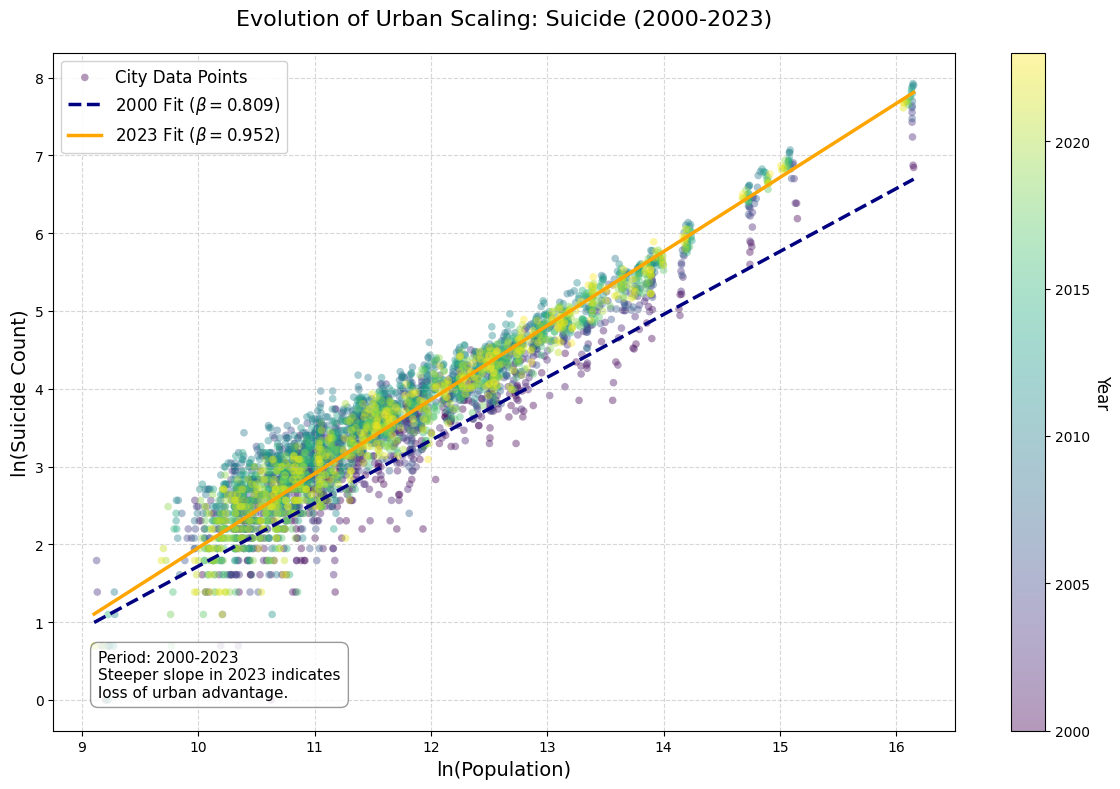

In [ ]:
# until 2023
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import os

# ========================================================
# [Step 1] Data Preparation
# ========================================================
# 파일 경로 확인 (Master_Panel_With_Divorce.csv 사용)
load_path = "/content/drive/MyDrive/Urban Scaling/Master_Panel_With_Divorce.csv"

# 데이터 로드
if os.path.exists(load_path):
    df_final = pd.read_csv(load_path)
else:
    print(f"[Error] 파일을 찾을 수 없습니다: {load_path}")
    # (참고) 이전 단계의 df_final이 메모리에 있다면 그대로 사용해도 됩니다.
    # df_final = df_final.copy()

# 1. 분석용 데이터 추출 (결측치 제거)
df_plot = df_final.dropna(subset=['Pop_Reg', 'Suicide_Count', 'Year']).copy()
df_plot = df_plot[(df_plot['Pop_Reg'] > 0) & (df_plot['Suicide_Count'] > 0)]

# 2. [수정됨] 2023년까지로 기간 한정 (Cut-off)
df_plot = df_plot[df_plot['Year'] <= 2023]

# 3. 로그 변환
df_plot['ln_Pop'] = np.log(df_plot['Pop_Reg'])
df_plot['ln_Suicide'] = np.log(df_plot['Suicide_Count'])

# 연도 범위 확인
min_year = df_plot['Year'].min()
max_year = df_plot['Year'].max()
print(f"=== 분석 기간: {min_year} ~ {max_year} ===")

# ========================================================
# [Step 2] Visualization
# ========================================================
fig, ax = plt.subplots(figsize=(12, 8))

# 1. Scatter Plot with Color Gradient (2000-2023)
sc = ax.scatter(
    df_plot['ln_Pop'],
    df_plot['ln_Suicide'],
    c=df_plot['Year'],
    cmap='viridis',
    alpha=0.4,
    edgecolor='none',
    s=30,
    label='City Data Points'
)

# 2. Colorbar (시간의 흐름 표시)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Year', rotation=270, labelpad=15, fontsize=12)

# 3. Regression Lines (Start vs End)
years_to_plot = [min_year, max_year]
colors = ['purple', 'gold'] # viridis 양 끝 색상과 매칭
labels = ['Start', 'End']

print("\n=== Regression Stats ===")
for year, color, label_type in zip(years_to_plot, colors, labels):
    sub_df = df_plot[df_plot['Year'] == year]

    # Linear Regression
    slope, intercept, r_val, p_val, std_err = stats.linregress(sub_df['ln_Pop'], sub_df['ln_Suicide'])
    print(f"Year {year}: Beta = {slope:.3f}, R2 = {r_val**2:.3f}")

    # Generate line
    x_range = np.linspace(df_plot['ln_Pop'].min(), df_plot['ln_Pop'].max(), 100)
    y_pred = intercept + slope * x_range

    # Plot line
    line_color = 'navy' if label_type == 'Start' else 'orange'
    linestyle = '--' if label_type == 'Start' else '-'

    ax.plot(x_range, y_pred, color=line_color, linewidth=2.5, linestyle=linestyle,
            label=f'{year} Fit ($\\beta={slope:.3f}$)')

# ========================================================
# [Step 3] Formatting
# ========================================================
ax.set_title(f'Evolution of Urban Scaling: Suicide ({min_year}-{max_year})', fontsize=16, pad=20)
ax.set_xlabel('ln(Population)', fontsize=14)
ax.set_ylabel('ln(Suicide Count)', fontsize=14)

# Grid and Legend
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=12, loc='upper left', frameon=True, framealpha=0.9)

# Annotation
ax.text(0.05, 0.05,
        f"Period: {min_year}-{max_year}\n"
        "Steeper slope in 2023 indicates\n"
        "loss of urban advantage.",
        transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.8))

plt.tight_layout()

# 저장
save_dir = "/content/drive/MyDrive/Urban Scaling/figures"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
save_path = os.path.join(save_dir, 'Suicide_Scaling_2000_2023_Overlay.jpg')
plt.savefig(save_path, dpi=300, format='jpg', bbox_inches='tight')

print(f"\nGraph saved to: {save_path}")
plt.show()

In [ ]:
df_final.columns

Index(['Year', 'City_Code', 'province', 'city_name', 'City_name_Kor',
       'city_name_Eng', 'Region_type', 'Pop_Reg', 'Suicide_Rate_100k',
       'Suicide_Count', 'Divorce_Rate', 'Divorce_Count'],
      dtype='object')

# categorization & visualization of suicide trajectory

=== Formal Test of Time-Scaling Interaction ===
                            OLS Regression Results                            
Dep. Variable:             ln_Suicide   R-squared:                       0.907
Model:                            OLS   Adj. R-squared:                  0.907
Method:                 Least Squares   F-statistic:                 1.234e+04
Date:                Tue, 27 Jan 2026   Prob (F-statistic):               0.00
Time:                        03:38:32   Log-Likelihood:                -1262.7
No. Observations:                3778   AIC:                             2533.
Df Residuals:                    3774   BIC:                             2558.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
In

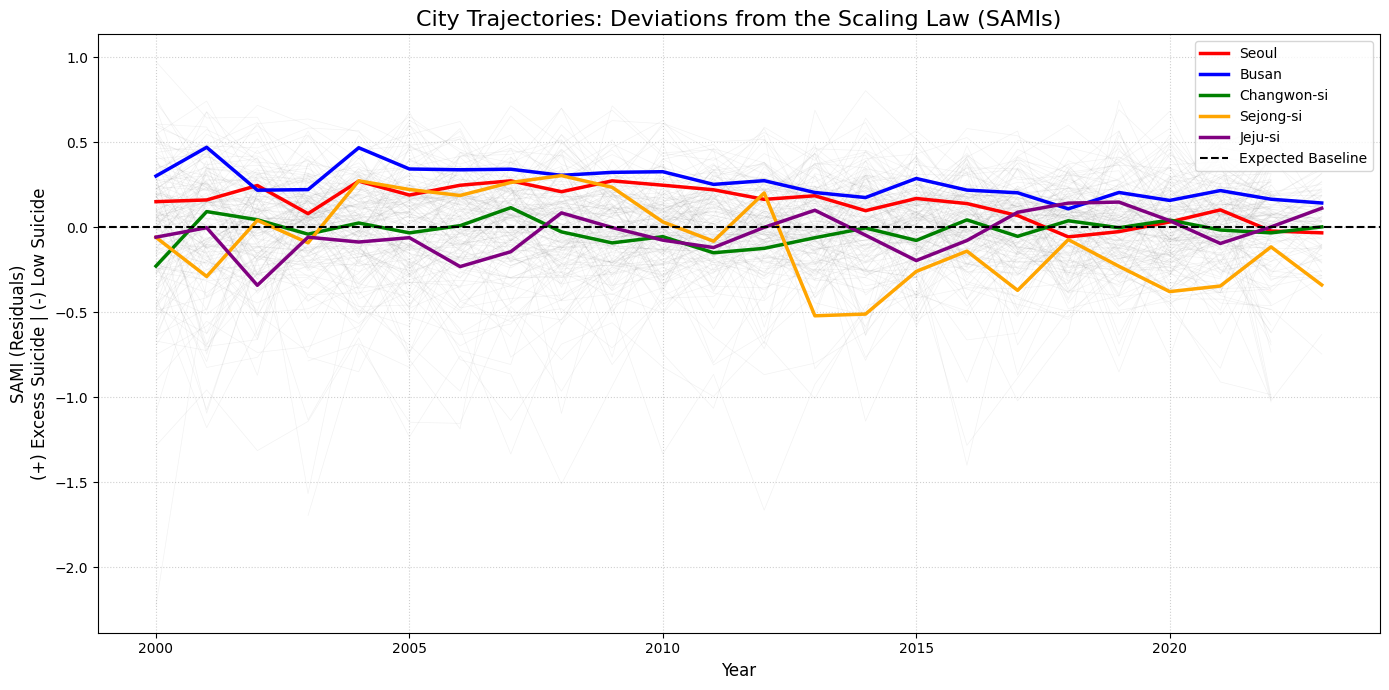

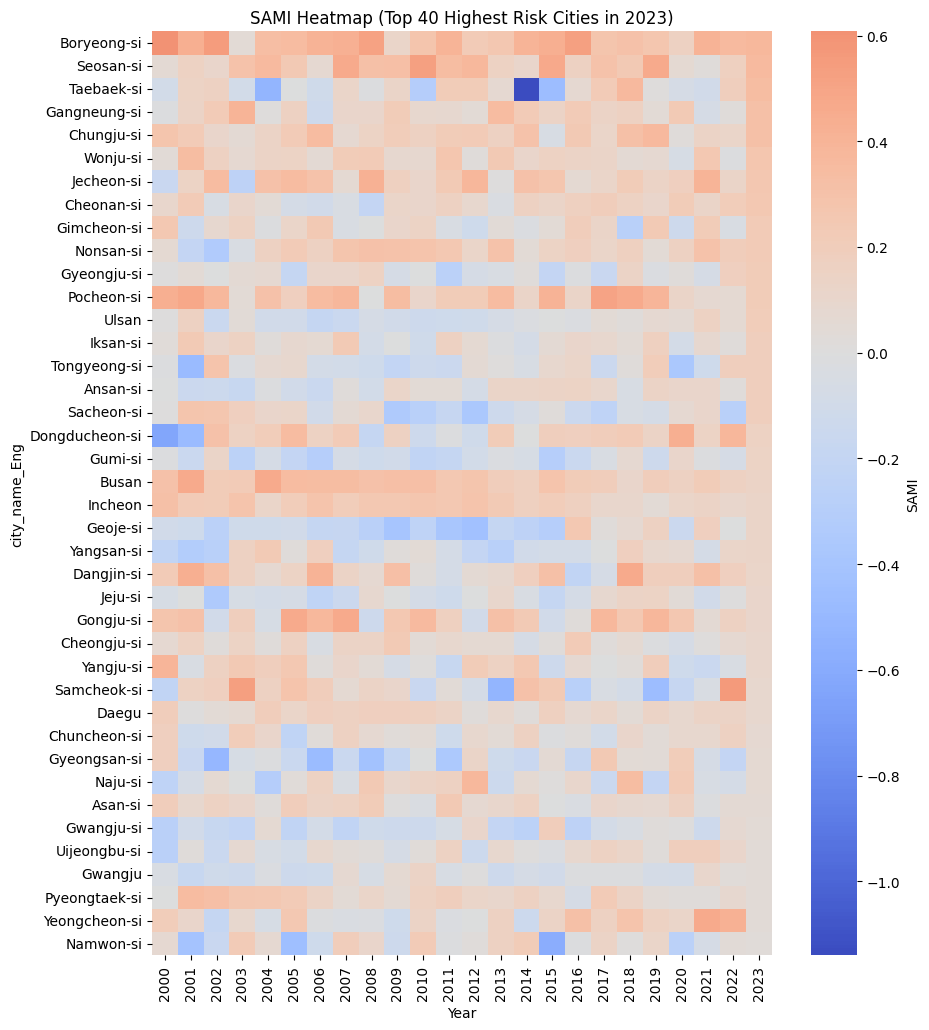

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# ========================================================
# [Step 1] Data Prep
# ========================================================
# Load your data (Assuming df_final is ready)
# df_final = pd.read_csv("Master_Panel_With_Divorce.csv") # Uncomment if needed

df_anal = df_final.dropna(subset=['Pop_Reg', 'Suicide_Count', 'Year']).copy()
df_anal = df_anal[(df_anal['Pop_Reg'] > 0) & (df_anal['Suicide_Count'] > 0)]
df_anal = df_anal[df_anal['Year'] <= 2023] # Cut-off

# Log-transform
df_anal['ln_Pop'] = np.log(df_anal['Pop_Reg'])
df_anal['ln_Suicide'] = np.log(df_anal['Suicide_Count'])

# ========================================================
# [Step 2] Formal Test: Interaction Model
# ========================================================
print("=== Formal Test of Time-Scaling Interaction ===")
# Model: ln(Y) ~ ln(N) * Year
# This tests if the slope (beta) depends on the Year.
model = smf.ols(formula='ln_Suicide ~ ln_Pop * Year', data=df_anal).fit()

print(model.summary())

interaction_p = model.pvalues['ln_Pop:Year']
interaction_coef = model.params['ln_Pop:Year']

print(f"\n[Result] Interaction Term (ln_Pop:Year):")
print(f" - Coefficient: {interaction_coef:.5f}")
print(f" - P-value:     {interaction_p:.5e}")

if interaction_p < 0.05:
    print("-> ★ SIGNIFICANT! The scaling exponent (beta) changes significantly over time.")
    if interaction_coef > 0:
        print("-> The positive coefficient confirms the slope is increasing (Steepening) over time.")
else:
    print("-> Not significant. The slope is stable.")

# ========================================================
# [Step 3] SAMI Calculation (Residuals)
# ========================================================
# Calculate SAMI for each year individually to remove the general systemic trend
# SAMI = Actual - Expected (for that specific year)
df_anal['SAMI'] = np.nan

years = sorted(df_anal['Year'].unique())
for year in years:
    # Fit scaling law for just this year
    sub_data = df_anal[df_anal['Year'] == year]
    slope, intercept = np.polyfit(sub_data['ln_Pop'], sub_data['ln_Suicide'], 1)

    # Calculate Expected Value
    expected_ln_suicide = intercept + slope * sub_data['ln_Pop']

    # Calculate Residual (SAMI)
    # SAMI > 0: Worse than expected (More suicide)
    # SAMI < 0: Better than expected (Less suicide)
    df_anal.loc[df_anal['Year'] == year, 'SAMI'] = sub_data['ln_Suicide'] - expected_ln_suicide

# ========================================================
# [Step 4] Categorization & Visualization (수정됨)
# ========================================================

# 1. Define Categories based on Mean SAMI and Trend (Slope of SAMI)
city_stats = []

# [수정] City_Name_Eng -> city_name_Eng
for city in df_anal['city_name_Eng'].unique():
    sub = df_anal[df_anal['city_name_Eng'] == city]
    if len(sub) < 10: continue # Skip if too few data points

    mean_sami = sub['SAMI'].mean()

    # Calculate trend of SAMI over time
    slope, _ = np.polyfit(sub['Year'], sub['SAMI'], 1)

    # Simple Categorization Logic
    if mean_sami > 0:
        status = "High Risk"
    else:
        status = "Low Risk"

    if slope > 0.01:
        trend = "Deteriorating" # Getting worse
    elif slope < -0.01:
        trend = "Improving"     # Getting better
    else:
        trend = "Stable"

    city_stats.append({
        'City': city,
        'Mean_SAMI': mean_sami,
        'SAMI_Trend': slope,
        'Category': f"{status} ({trend})"
    })

df_stats = pd.DataFrame(city_stats)
print("\n=== City Categorization Examples ===")
print(df_stats[['City', 'Category', 'Mean_SAMI']].head())

# 2. Visualization: SAMI Trajectories
plt.figure(figsize=(14, 7))

# [수정] units='City_Name_Eng' -> units='city_name_Eng'
sns.lineplot(data=df_anal, x='Year', y='SAMI', units='city_name_Eng', estimator=None,
             color='gray', alpha=0.1, lw=0.5)

# Highlight a few interesting cities
target_cities = ['Seoul', 'Busan', 'Changwon', 'Sejong', 'Jeju']

colors = ['red', 'blue', 'green', 'orange', 'purple']

for city, color in zip(target_cities, colors):
    # [수정] 'City_Name_Eng' -> 'city_name_Eng'
    sub = df_anal[df_anal['city_name_Eng'].str.contains(city, case=False, na=False)]
    if not sub.empty:
        unique_codes = sub['City_Code'].unique()
        for code in unique_codes:
            city_data = sub[sub['City_Code'] == code]
            # [수정]
            real_name = city_data['city_name_Eng'].iloc[0]
            plt.plot(city_data['Year'], city_data['SAMI'],
                     color=color, linewidth=2.5, label=real_name)

plt.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Expected Baseline')
plt.title('City Trajectories: Deviations from the Scaling Law (SAMIs)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('SAMI (Residuals)\n(+) Excess Suicide | (-) Low Suicide', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 3. (Optional) Heatmap of Trajectories
# [수정] index='City_Name_Eng' -> index='city_name_Eng'
pivot_sami = df_anal.pivot_table(index='city_name_Eng', columns='Year', values='SAMI')
pivot_sami = pivot_sami.sort_values(by=2023, ascending=False)

plt.figure(figsize=(10, 12))
sns.heatmap(pivot_sami.iloc[:40], cmap='coolwarm', center=0, cbar_kws={'label': 'SAMI'})
plt.title('SAMI Heatmap (Top 40 Highest Risk Cities in 2023)')
plt.show()

K-Means Clustering을 적용하여 도시들을 4개의 그룹(예: 고위험, 저위험, 악화, 개선)으로 나누고, 이를 바탕으로 Spaghetti Plot과 Heatmap을 모두 개선

/tmp/ipython-input-3726188963.py:17: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  pivot_sami_filled = pivot_sami.fillna(method='ffill', axis=1).fillna(method='bfill', axis=1).dropna()


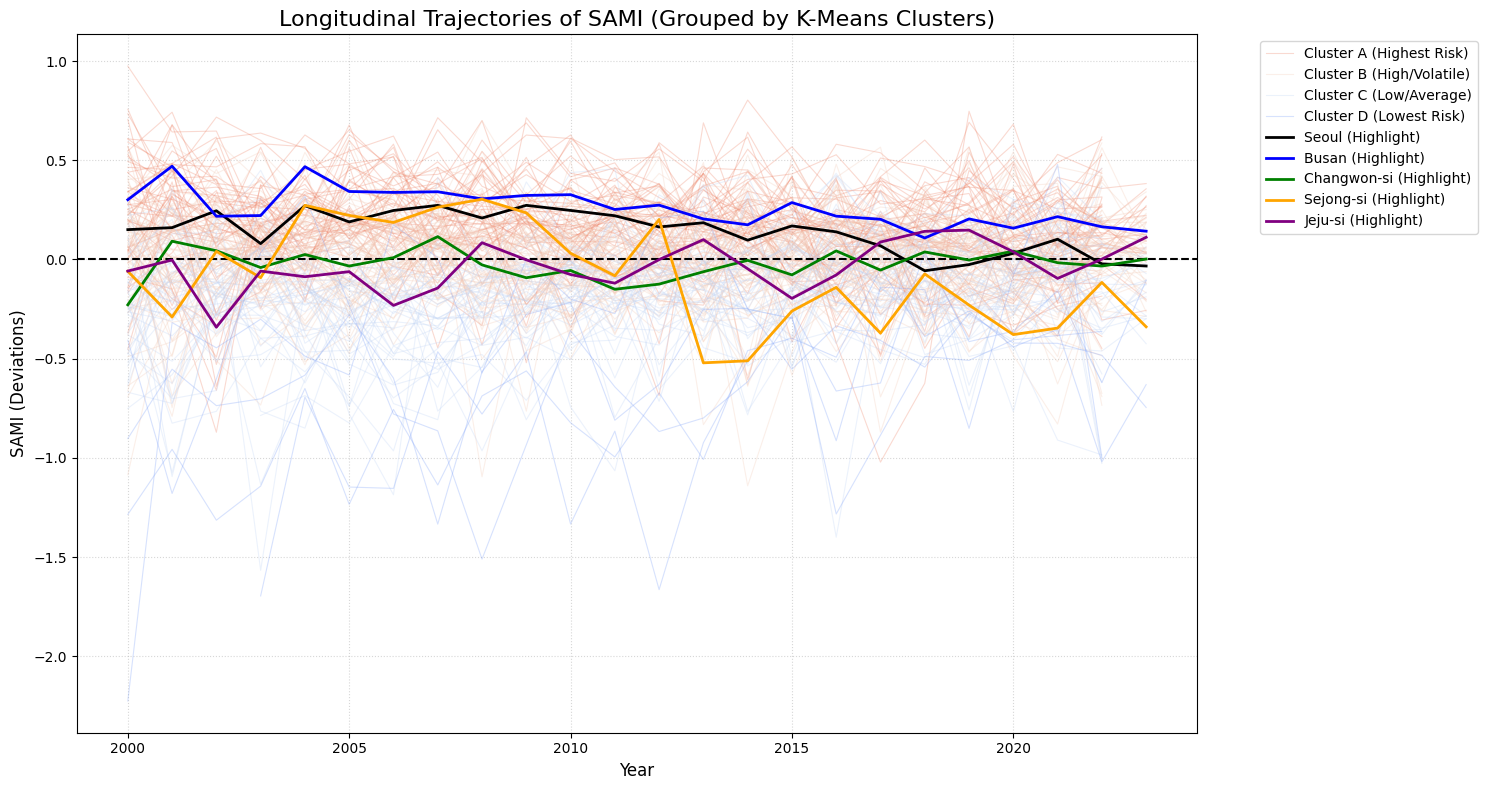

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ========================================================
# [Step 1] Data Preparation for Clustering
# ========================================================
# Pivot Data: Index=City, Columns=Year, Values=SAMI
# 'city_name_Eng' 사용 (대소문자 주의)
pivot_sami = df_anal.pivot_table(index='city_name_Eng', columns='Year', values='SAMI')

# 결측치가 하나라도 있는 도시는 클러스터링에서 제외하거나 채워야 함
# 여기서는 간단히 dropna를 하거나(엄격), ffill/bfill로 채움
pivot_sami_filled = pivot_sami.fillna(method='ffill', axis=1).fillna(method='bfill', axis=1).dropna()

# 정규화 (Clustering을 위해) - 도시별 패턴(모양)을 중시할지, 절대값(위치)을 중시할지 결정
# SAMI는 절대값이 중요하므로(0보다 크냐 작냐), 정규화를 안 하거나 0을 중심으로 함.
# 여기서는 원본 SAMI 값을 그대로 씁니다. (SAMI 자체가 이미 Log scale residual이라 정규화된 성격임)

# ========================================================
# [Step 2] K-Means Clustering
# ========================================================
# 4개 그룹으로 분류 (예: High Stable, Low Stable, Worsening, Improving)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
pivot_sami_filled['Cluster'] = kmeans.fit_predict(pivot_sami_filled)

# 클러스터의 특성 파악 (평균 SAMI 순으로 재정렬하여 0~3번 번호 부여)
cluster_means = pivot_sami_filled.groupby('Cluster').mean().mean(axis=1)
mapping = {old_label: new_label for new_label, old_label in enumerate(cluster_means.sort_values(ascending=False).index)}
pivot_sami_filled['Cluster'] = pivot_sami_filled['Cluster'].map(mapping)

# 클러스터 이름 정의 (평균값과 추세를 보고 수동으로 붙여주면 좋음, 여기서는 자동화)
# 0: Highest Risk, 3: Lowest Risk
cluster_labels = {
    0: 'Cluster A (Highest Risk)',
    1: 'Cluster B (High/Volatile)',
    2: 'Cluster C (Low/Average)',
    3: 'Cluster D (Lowest Risk)'
}

# 원본 데이터에 클러스터 정보 병합
cluster_map = pivot_sami_filled['Cluster'].to_dict()
df_anal['Cluster_ID'] = df_anal['city_name_Eng'].map(cluster_map)
df_anal['Cluster_Name'] = df_anal['Cluster_ID'].map(cluster_labels)

# ========================================================
# [Step 3] Improved Spaghetti Plot (Color by Cluster)
# ========================================================
plt.figure(figsize=(15, 8))

# 클러스터별 색상 지정
palette = sns.color_palette("coolwarm_r", 4) # Red(Risk) to Blue(Safe)

# 1. 배경 선들을 클러스터 색으로 칠함 (회색 대신) -> 가시성 확보
# units 파라미터를 사용하여 도시별로 그립니다.
sns.lineplot(
    data=df_anal.dropna(subset=['Cluster_ID']),
    x='Year',
    y='SAMI',
    hue='Cluster_Name',
    units='city_name_Eng',
    estimator=None,
    palette=palette,
    alpha=0.3,   # 투명도: 0.1 -> 0.3으로 올려서 더 잘 보이게
    linewidth=0.8 # 선 두께: 약간 두껍게
)

# 2. 특정 도시 강조 (Highlight) - 선 두께 조절 (2.5 -> 2.0)
target_cities = ['Seoul', 'Busan', 'Changwon-si', 'Sejong-si', 'Jeju-si']
highlight_colors = ['black', 'blue', 'green', 'orange', 'purple'] # 서울은 검정으로

for city, color in zip(target_cities, highlight_colors):
    sub = df_anal[df_anal['city_name_Eng'].str.contains(city, case=False, na=False)]
    if not sub.empty:
        # 도시 이름 정확히 가져오기
        real_name = sub['city_name_Eng'].iloc[0]
        # 해당 도시가 어느 클러스터인지 확인 (범례 표시용)
        # c_id = sub['Cluster_Name'].iloc[0]

        plt.plot(sub['Year'], sub['SAMI'],
                 color=color,
                 linewidth=2.0, # 너무 두껍지 않게 조정
                 label=f"{real_name} (Highlight)",
                 zorder=10) # 맨 위에 그리기

plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Longitudinal Trajectories of SAMI (Grouped by K-Means Clusters)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('SAMI (Deviations)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # 범례 밖으로 뺌
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# ========================================================
# [Step 4] Improved Heatmap (Sorted by Cluster)
# ========================================================
# 클러스터 순서대로 정렬 + 클러스터 내에서는 2023년 값(최근 값) 기준으로 정렬
pivot_sami_filled['Mean_SAMI'] = pivot_sami_filled.drop('Cluster', axis=1).mean(axis=1)
pivot_sami_sorted = pivot_sami_filled.sort_values(by=['Cluster', 'Mean_SAMI'], ascending=[True, False])

# 히트맵 그리기용 데이터 (메타 데이터 제외)
heatmap_data = pivot_sami_sorted.drop(['Cluster', 'Mean_SAMI'], axis=1)

plt.figure(figsize=(12, 20)) # 세로로 길게
# 전체 도시를 다 그리면 글자가 겹치므로, 클러스터별로 상위/하위 일부를 뽑거나,
# 혹은 전체를 그리되 y축 레이블을 조정해야 함.
# 여기서는 전체 패턴을 보기 위해 y축 레이블 글자 크기를 줄여서 다 그립니다.

sns.heatmap(heatmap_data, cmap='coolwarm', center=0, cbar_kws={'label': 'SAMI'})

# 클러스터 구분선 그리기
cluster_counts = pivot_sami_sorted['Cluster'].value_counts().sort_index()
current_y = 0
for cluster_id, count in cluster_counts.items():
    current_y += count
    plt.axhline(current_y, color='black', linewidth=1)
    # 클러스터 이름 표시
    plt.text(2024, current_y - (count/2), cluster_labels[cluster_id],
             verticalalignment='center', fontsize=12, fontweight='bold')

plt.title('SAMI Heatmap: Cities Organized by Behavioral Clusters', fontsize=16)
plt.yticks(fontsize=6) # 폰트 작게해서 최대한 많이 보이게
plt.show()

각 도시의 **평균 SAMI(위치)**와 **SAMI 기울기(속도)**를 계산하여 4분면에 배치하고, 주요 도시의 이름만 라벨링하여 가독성을 높임

In [ ]:
!pip install adjustText

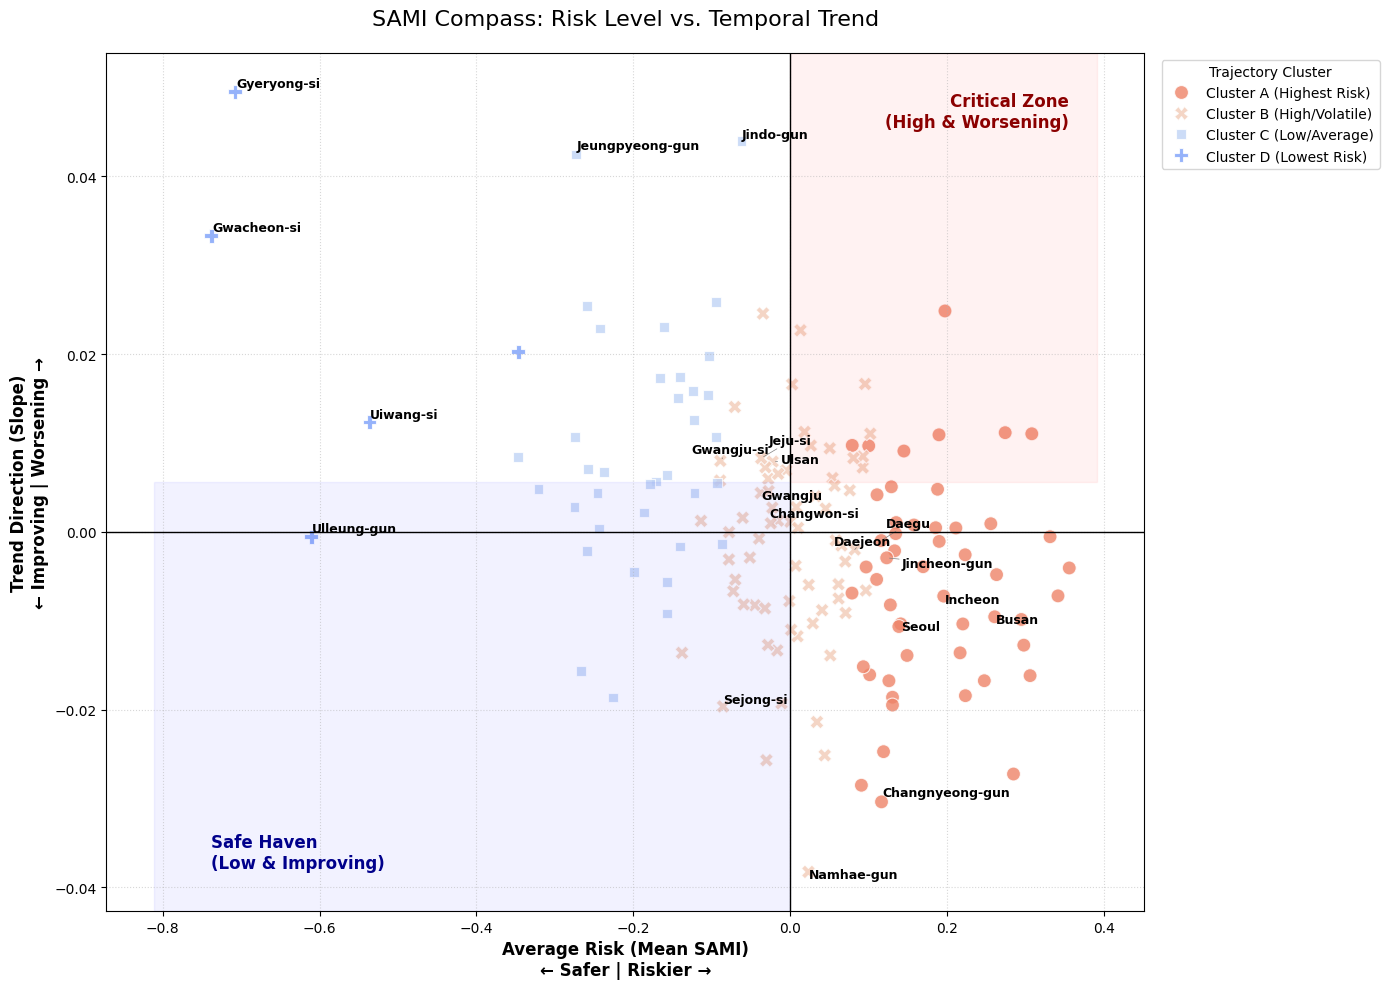


=== City List by Quadrant (Top 5 per group by magnitude) ===

[Q1: Critical (High & Worsening)]
Taean-gun, Cheongyang-gun, Seosan-si, Hoengseong-gun, Jeongseon-gun, Seocheon-gun, Jecheon-si, Chungju-si, Buan-gun, Nonsan-si

[Q2: Deteriorating Safe (Low but Worsening)]
Gwacheon-si, Gyeryong-si, Uiwang-si, Gunpo-si, Gokseong-gun, Hanam-si, Guri-si, Wando-gun, Jeungpyeong-gun, Yeongdeok-gun

[Q3: Safe Haven (Low & Improving)]
Ulleung-gun, Damyang-gun, Muju-gun, Uljin-gun, Yongin-si, Jinan-gun, Sinan-gun, Sunchang-gun, Gimpo-si, Geochang-gun

[Q4: Improving Risk (High but Improving)]
Boryeong-si, Hongcheon-gun, Hongseong-gun, Yeongwol-gun, Yangyang-gun, Yesan-gun, Goesan-gun, Pocheon-si, Busan, Gimje-si


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text  # 텍스트 겹침 방지 (없으면 pip install adjustText 필요)
# adjustText가 없는 환경을 대비해 try-except 처리 혹은 기본 text 사용

# ========================================================
# [Step 1] Metric Calculation (Mean & Trend)
# ========================================================
city_metrics = []

# df_anal은 이전 단계에서 SAMI가 계산된 데이터프레임
# Cluster 정보가 있다면 그것도 활용
cluster_map = df_anal.set_index('city_name_Eng')['Cluster_Name'].to_dict()

for city in df_anal['city_name_Eng'].unique():
    sub = df_anal[df_anal['city_name_Eng'] == city]
    if len(sub) < 10: continue # 데이터 부족한 도시 제외

    # 1. Mean SAMI (평균적 위험도)
    mean_sami = sub['SAMI'].mean()

    # 2. SAMI Trend (기울기: 악화/개선 속도)
    # np.polyfit(x, y, 1) -> [slope, intercept]
    slope, _ = np.polyfit(sub['Year'], sub['SAMI'], 1)

    # 3. Cluster (이전 단계에서 구한 클러스터)
    cluster = cluster_map.get(city, "Unknown")

    city_metrics.append({
        'City': city,
        'Mean_SAMI': mean_sami,
        'Trend_Slope': slope,
        'Cluster': cluster
    })

df_quadrant = pd.DataFrame(city_metrics)

# ========================================================
# [Step 2] Visualization: The Quadrant Plot
# ========================================================
plt.figure(figsize=(14, 10))

# 1. Scatter Plot
# Cluster별로 색상과 마커 모양을 다르게
sns.scatterplot(
    data=df_quadrant,
    x='Mean_SAMI',
    y='Trend_Slope',
    hue='Cluster',
    style='Cluster',
    s=100, # 점 크기
    palette='coolwarm_r', # Red(Risk) to Blue(Safe)
    alpha=0.8
)

# 2. Draw Quadrant Lines (Crosshair)
plt.axhline(0, color='black', linestyle='-', linewidth=1) # X축 (Trend=0)
plt.axvline(0, color='black', linestyle='-', linewidth=1) # Y축 (Mean=0)

# 3. Quadrant Background Colors (Optional: 배경색으로 영역 구분)
# 우상단 (1사분면): High Risk & Worsening (가장 위험)
plt.axvspan(0, df_quadrant['Mean_SAMI'].max()*1.1, ymin=0.5, ymax=1, color='red', alpha=0.05)
# 좌하단 (3사분면): Low Risk & Improving (가장 안전)
plt.axvspan(df_quadrant['Mean_SAMI'].min()*1.1, 0, ymin=0, ymax=0.5, color='blue', alpha=0.05)

# 4. Annotations (도시 이름 표시)
# 모든 도시를 표시하면 복잡하므로, '주요 도시' + '양극단 도시(Outliers)'만 표시
texts = []
major_cities = ['Seoul', 'Busan', 'Incheon', 'Daegu', 'Gwangju', 'Daejeon', 'Ulsan', 'Sejong-si', 'Changwon-si', 'Jeju-si']

for i, row in df_quadrant.iterrows():
    is_major = any(c.lower() in row['City'].lower() for c in major_cities)
    is_outlier = (abs(row['Mean_SAMI']) > 0.4) or (abs(row['Trend_Slope']) > 0.03) # 기준은 데이터 분포 보고 조정

    if is_major or is_outlier:
        texts.append(plt.text(row['Mean_SAMI'], row['Trend_Slope'], row['City'], fontsize=9, fontweight='bold'))

# 텍스트 겹침 방지 (adjustText 라이브러리가 설치되어 있다면)
try:
    from adjustText import adjust_text
    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
except ImportError:
    pass # 설치 안 되어 있으면 그냥 겹친 채로 둠 (기본 text 사용)

# 5. Formatting
plt.title('SAMI Compass: Risk Level vs. Temporal Trend', fontsize=16, pad=20)
plt.xlabel('Average Risk (Mean SAMI)\n← Safer | Riskier →', fontsize=12, fontweight='bold')
plt.ylabel('Trend Direction (Slope)\n← Improving | Worsening →', fontsize=12, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title='Trajectory Cluster')

# 4분면 설명 텍스트 추가
plt.text(df_quadrant['Mean_SAMI'].max(), df_quadrant['Trend_Slope'].max(), "Critical Zone\n(High & Worsening)",
         ha='right', va='top', color='darkred', fontweight='bold', fontsize=12)
plt.text(df_quadrant['Mean_SAMI'].min(), df_quadrant['Trend_Slope'].min(), "Safe Haven\n(Low & Improving)",
         ha='left', va='bottom', color='darkblue', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# ========================================================
# [Step 3] Print List by Quadrant (Text Summary)
# ========================================================
# 4분면 정의
def define_quadrant(row):
    if row['Mean_SAMI'] > 0 and row['Trend_Slope'] > 0:
        return "Q1: Critical (High & Worsening)"
    elif row['Mean_SAMI'] < 0 and row['Trend_Slope'] > 0:
        return "Q2: Deteriorating Safe (Low but Worsening)"
    elif row['Mean_SAMI'] < 0 and row['Trend_Slope'] < 0:
        return "Q3: Safe Haven (Low & Improving)"
    else:
        return "Q4: Improving Risk (High but Improving)"

df_quadrant['Quadrant'] = df_quadrant.apply(define_quadrant, axis=1)

print("\n=== City List by Quadrant (Top 5 per group by magnitude) ===")
for q in sorted(df_quadrant['Quadrant'].unique()):
    print(f"\n[{q}]")
    # 해당 분면에 속한 도시 중 SAMI 절대값이 큰 순서대로 5개 출력
    sub = df_quadrant[df_quadrant['Quadrant'] == q].copy()
    sub['abs_SAMI'] = sub['Mean_SAMI'].abs()
    top_cities = sub.sort_values(by='abs_SAMI', ascending=False).head(10)['City'].tolist()
    print(", ".join(top_cities))